# Copy-trading des trades du Congrès US (2014-2026) : y a-t-il un signal exploitable ?

*Recherche QIS — Ramify. Données STOCK Act (House + Sénat), 2014-2026, source-primaire canonique.*

## La question
- En répliquant les **achats** déclarés du Congrès, obtient-on un rendement **anormal** assez robuste pour un produit ?
- On distingue **rendement brut** (peut n'être que du beta), **alpha** (résiduel après facteurs), **Sharpe** (vs indice investissable).

## La réponse
- **Loterie à queue droite** : moyenne positive tirée par une poignée de gagnants, médiane négative.
- **Aucun alpha** : en portefeuille, l'alpha factoriel est nul voire **significativement négatif**.
- **Rien ne bat SPY** en risque-ajusté, à aucune pondération ni sélection ; DSR < 0,95 après data-mining.
- Verdict : **produit thématique**, **pas** un générateur d'alpha.

## Données & structure
- Table clean canonique `transactions_backtest_2014_2026.csv` + prix ajustés `prices_v2` + facteurs Fama-French-Carhart. Aucun réseau.
- **Partie 0** = moteur (fonctions, maths) ; **Parties 1-6** = recherche. Zéro chiffre orphelin.

# Partie 0 — La boîte à outils (le moteur)

- Définit tout ce qu'utilisent les Parties 1-6 ; ne tire aucune conclusion.
- Plan : imports (0.1) → transactions (0.2) → prix/facteurs/benchmarks (0.3) → rendement anormal (0.4) → portefeuille (0.5) → tests d'alpha (0.6) → GRS (0.7) → Sharpe (0.8) → niveau-trade (0.9) → sélection PIT des membres (0.10) → fondations (0.13).

## 0.1 — Imports & chemins (autonome)

- `numpy`/`pandas` (calcul vectoriel, tables datées), `scipy.stats` (loi *F* pour GRS, normale pour *p*-values), `statsmodels` (OLS + erreurs **HAC** Newey-West, car rendements auto-corrélés).
- Chemins : dossier `02_recherche_backtest` contenant `cache/prices/`.
- **Survivorship** : le cache ne contient **que les titres encore cotés**. Les délistés (faillites, rachats) sont absents → tous nos chiffres sont une **borne haute**.

In [1]:
import os, re, time, warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ── chemins (autonome) — DONNÉE CLEAN canonique + cache prices_v2 (aligné 05b) ──
S3 = None
for base in [os.path.expanduser('~/Downloads/Jupiter'), os.path.expanduser('~/Downloads/0. Jupiter')]:
    p = Path(base) / '02_recherche_backtest'
    if (p/'cache'/'prices_v2').exists(): S3 = p; break
REPO  = S3.parent
CACHE = S3/'cache'; PX = CACHE/'prices_v2'
CLEAN = REPO/'00_recuperation_donnees'/'data'/'clean'/'transactions_backtest_2014_2026.csv' 

## 0.2 — Le journal des transactions

- `load_transactions(min_year, max_year)` : lit le CSV, parse `traded` (date transaction) et `filed` (date de **déclaration**, ce qu'un copieur observe), borne `size_usd` au **plancher 1001 $** (STOCK Act ne déclare que des fourchettes → borne basse, sous-estimation prudente), filtre `filed ∈ [min_year, max_year]`.
- `buy_signals(df)` : garde les **achats** (`op == 'buy'`) à **ticker coté** uniquement.
- **Hypothèse** : un achat est exploitable au plus tôt à `filed`.

In [2]:
MIN_BRACKET = 1001.0
def load_transactions(min_year=2014, max_year=2026):
    # Table PROPRE canonique source-primaire (même donnée que 05b) ; ticker_yahoo = ticker CLEAN
    df = pd.read_csv(CLEAN, low_memory=False)
    df = (df.drop(columns=['ticker'])
            .rename(columns={'disclosure_date':'filed', 'transaction_date':'traded', 'direction':'op',
                             'ticker_yahoo':'ticker', 'amount_midpoint':'size_usd',
                             'bioguide_id':'bioguide', 'member_name':'name'}))
    df['source'] = 'source-primaire'                                            # canonique mono-source
    df['traded']=pd.to_datetime(df['traded'],errors='coerce'); df['filed']=pd.to_datetime(df['filed'],errors='coerce')
    df['size_usd']=pd.to_numeric(df['size_usd'],errors='coerce').clip(lower=MIN_BRACKET)
    df['ticker']=df['ticker'].replace('',np.nan)
    df=df[df['filed'].notna()&df['traded'].notna()]
    return df[(df['filed'].dt.year>=min_year)&(df['filed'].dt.year<=max_year)].reset_index(drop=True)
def buy_signals(df): return df[(df['op']=='buy')&df['ticker'].notna()].copy().reset_index(drop=True)

## 0.3 — Prix, facteurs, benchmarks

- `load_panel(tickers)` : `DataFrame` (dates × tickers) depuis les CSV du cache ; seuls les tickers en cache → re-matérialise le **survivorship**.
- `get_bench(name)` : **SPY** (cap-weight, dominé par les méga-caps tech), **RSP** (S&P 500 équipondéré), **ETF SPDR sectoriels** (classification **GICS**, table `GICS_TO_ETF`).
- `get_factors()` : facteurs quotidiens **Fama-French-Carhart** — `Mkt-RF`, `SMB` (taille), `HML` (value), `Mom` (momentum), `RF`.

In [3]:
def load_panel(tickers):
    cols={}
    for t in dict.fromkeys(tickers):
        f=PX/f'{t}.csv'
        if f.exists(): cols[t]=pd.read_csv(f,index_col=0,parse_dates=True)['close']
    return pd.DataFrame(cols).sort_index()
def get_bench(name): return pd.read_csv(PX/f'{name}.csv',index_col=0,parse_dates=True)['close']
def get_factors(): return pd.read_csv(CACHE/'ff_factors.csv',index_col=0,parse_dates=True)

GICS_TO_ETF={'Energy':'XLE','Materials':'XLB','Industrials':'XLI','Consumer Discretionary':'XLY',
 'Consumer Staples':'XLP','Health Care':'XLV','Financials':'XLF','Information Technology':'XLK',
 'Communication Services':'XLC','Utilities':'XLU','Real Estate':'XLRE'}

## 0.4 — Le rendement anormal (AR)

- **Mesure** : de combien un achat a-t-il **battu son benchmark** sur un horizon ?
- Notation : `Pi`, `Pj` = cours du titre en début/fin d'horizon ; `Bi`, `Bj` = benchmark aux mêmes dates.

$$AR = \left(\frac{P_j}{P_i}-1\right) - \left(\frac{B_j}{B_i}-1\right)$$

- `AR > 0` = l'achat a fait mieux que la référence.
- **Hypothèses** : entrée à `filed` ; horizons en **jours de bourse** ; fenêtre débordant les données → `None`.
- **Benchmarks** : SPY soustrait le signal (méga-caps tech), RSP plus juste, sectoriel le plus neutre (garde la sélection intra-secteur).
- **Horizons** : **21 / 63 / 126 / 252** jours (≈ 1 / 3 / 6 / 12 mois).

In [4]:
def abn_return(px, bench, entry, horizon_days):
    px,bench=px.dropna(),bench.dropna()
    i=px.index.searchsorted(pd.Timestamp(entry)); j=i+horizon_days
    if i>=len(px) or j>=len(px) or px.iloc[i]<=0: return None
    bi,bj=bench.index.searchsorted(px.index[i]),bench.index.searchsorted(px.index[j])
    if bi>=len(bench) or bj>=len(bench): return None
    return (px.iloc[j]/px.iloc[i]-1.0)-(bench.iloc[bj]/bench.iloc[bi]-1.0)
def abn_col(bdf, bench, h, use_sector=False):
    """Vecteur d'AR (horizon h jours) pour chaque ligne de bdf ; bench secteur si use_sector."""
    out=[]
    for t,f in zip(bdf['ticker'],bdf['filed']):
        if t not in panel.columns: out.append(np.nan); continue
        b=etfp[t2etf[t]] if (use_sector and t in t2etf and t2etf[t] in etfp.columns) else bench
        v=abn_return(panel[t],b,f,h); out.append(np.nan if v is None else v)
    return np.array(out)

## 0.5 — Le portefeuille (règle « Ramify »)

- **Entrée** = `filed + 1 jour` (`lag_days=1`, pas de look-ahead). **Sortie** = vente déclarée du même membre/titre si elle existe (`SELL_MAP`), sinon **+12 mois** (`horizon_months`).
- **Pondérations** (`weighting`) : `equal` (1/trade), `size` (∝ `size_usd`, borne basse), `sqrt_size` (∝ √`size_usd`).
- **Coûts** : **20 bps** sur le turnover `|w_t − w_{t-1}|`. **Anti-glitch** : rendements winsorisés à **±50 %/jour** (`clip(-0.5,0.5)`).
- **Sorties** : `run_portfolio(...)['net']` (rendements nets) ; `ann_stats(daily)` → `CAGR`, `vol` (=σ×√252), `sharpe` (=moyenne/σ×√252, RF nul), `maxDD` ; `bench_daily(price, idx)`.

In [5]:
def build_sell_map(df_all):
    sells=df_all[(df_all['op']=='sell')&df_all['ticker'].notna()]
    return {k:np.sort(g['filed'].values) for k,g in sells.groupby(['bioguide','ticker'])}
def build_positions(buys, df_all, horizon_months=12, sell_map=None):
    if sell_map is None: sell_map=build_sell_map(df_all)
    H=pd.DateOffset(months=horizon_months); rows=[]
    for r in buys.itertuples(index=False):
        forced=r.filed+H; arr=sell_map.get((r.bioguide,r.ticker)); ex=forced
        if arr is not None:
            later=arr[arr>np.datetime64(r.filed)]
            if len(later): ex=min(forced,pd.Timestamp(later[0]))
        rows.append((r.bioguide,r.ticker,r.filed,ex,float(r.size_usd)))
    return pd.DataFrame(rows,columns=['bioguide','ticker','entry','exit','size_usd'])
def run_portfolio(positions, panel, weighting='size', cost_bps=20.0, lag_days=1):
    idx=panel.index; tpos={t:i for i,t in enumerate(panel.columns)}
    ret=panel.pct_change(fill_method=None).clip(-0.5,0.5).fillna(0.0).values; D,N=ret.shape
    pos=positions[positions['ticker'].isin(tpos)].copy()
    if len(pos)==0: return {'gross':pd.Series(0.0,index=idx),'net':pd.Series(0.0,index=idx),'n_positions':0}
    if 'raw' in pos.columns:      raw=pos['raw'].values.astype(float)
    elif weighting=='size':       raw=pos['size_usd'].values.astype(float)
    elif weighting=='sqrt_size':  raw=np.sqrt(pos['size_usd'].values.astype(float))
    else:                         raw=np.ones(len(pos))
    ei=idx.searchsorted(pos['entry'].values+np.timedelta64(lag_days,'D'),side='left')
    xi=idx.searchsorted(pos['exit'].values,side='left'); ti=pos['ticker'].map(tpos).values
    dl=np.zeros((D+1,N)); ok=ei<D
    np.add.at(dl,(ei[ok],ti[ok]),raw[ok]); np.add.at(dl,(np.clip(xi,0,D)[ok],ti[ok]),-raw[ok])
    h=np.cumsum(dl[:D],axis=0); h[h<0]=0.0; tot=h.sum(1,keepdims=True)
    w=np.divide(h,tot,out=np.zeros_like(h),where=tot>0); wp=np.vstack([np.zeros((1,N)),w[:-1]])
    gross=(wp*ret).sum(1); cost=(cost_bps/1e4)*np.abs(w-wp).sum(1)
    return {'gross':pd.Series(gross,index=idx),'net':pd.Series(gross-cost,index=idx),'n_positions':len(pos)}
def ann_stats(d):
    d=d.dropna(); y=len(d)/252
    return {'CAGR':(1+d).prod()**(1/y)-1,'vol':d.std()*np.sqrt(252),
            'sharpe':d.mean()/d.std()*np.sqrt(252) if d.std()>0 else np.nan,
            'maxDD':((1+d).cumprod()/(1+d).cumprod().cummax()-1).min()}
def bench_daily(price, idx): return price.reindex(idx).ffill().pct_change(fill_method=None).fillna(0.0)

## 0.6 — Famille ALPHA (CAPM / FF3 / FFC4), erreurs HAC

- **Question** : vrai alpha (talent) ou rémunération de facteurs de risque connus ?
- On régresse le rendement excédentaire `r − RF` sur 1/3/4 facteurs : `capm` (`Mkt-RF`), `ff3` (+`SMB`+`HML`), `ffc4` (+`Mom`).

$$r_t - RF_t = \alpha + \sum_k \beta_k f_{k,t} + \varepsilon_t$$

- L'**intercept `α`** = rendement **non expliqué** par les facteurs.
- **Erreurs HAC** (Newey-West, `maxlags=5`) : corrige auto-corrélation et hétéroscédasticité ; sinon les *t* sont gonflés.
- **Sorties** : `alpha_annuel` = `α·252`, `alpha_t` (|t| ≳ 2 pour être significatif), `beta_marche`, `beta_t`, `R2`.
- **Lecture** : un gros CAGR porté par un beta élevé n'est **pas** de l'alpha. Le facteur marché reste **cap-weight** (définition canonique Fama-French) : test d'alpha volontairement exigeant.

In [6]:
_FCOLS={'capm':['Mkt-RF'],'ff3':['Mkt-RF','SMB','HML'],'ffc4':['Mkt-RF','SMB','HML','Mom']}
def factor_alpha(daily, factors, model='ffc4'):
    f=factors.reindex(daily.index).dropna()
    if len(f)<60: return {'alpha_annuel':np.nan,'alpha_t':np.nan,'beta_marche':np.nan,'beta_t':np.nan,'R2':np.nan}
    y=(daily.reindex(f.index)-f['RF']).values
    cols=[c for c in _FCOLS[model] if c in f.columns]
    X=np.column_stack([np.ones(len(f))]+[f[c].values for c in cols])
    res=sm.OLS(y,X).fit(cov_type='HAC',cov_kwds={'maxlags':5})
    return {'alpha_annuel':res.params[0]*252,'alpha_t':res.tvalues[0],
            'beta_marche':res.params[1],'beta_t':res.tvalues[1],'R2':res.rsquared}

## 0.7 — Le test GRS (Gibbons-Ross-Shanken)

- **Mesure** : teste **un panier entier** de portefeuilles d'un coup (garde-fou anti cherry-picking).
- $H_0$ : **tous les alphas conjointement = 0**.
- Notation : `T` = périodes, `N` = portefeuilles, `L` = facteurs ; `α` = intercepts, `Σ` = covariance des résidus, `f̄` = moyenne des facteurs, `Ω` = covariance des facteurs.

$$GRS = \frac{T}{N}\cdot\frac{T-N-L}{T-L-1}\cdot\frac{\alpha'\Sigma^{-1}\alpha}{1+\bar f'\,\Omega^{-1}\bar f}\ \sim\ F(N,\,T-N-L)$$

- `p < 0,05` ⇒ rejet de $H_0$ ⇒ au moins un alpha non nul.
- **Précaution** : portefeuilles **non chevauchants** requis → appliqué à une partition (2×2 chambre × commission, ou déciles).

In [7]:
def grs_test(R, F):
    R,F=R.align(F,join='inner',axis=0); T,N=R.shape; L=F.shape[1]
    X=np.column_stack([np.ones(T),F.values]); B=np.linalg.lstsq(X,R.values,rcond=None)[0]
    alpha=B[0]; resid=R.values-X@B; Sigma=(resid.T@resid)/(T-L-1)
    fbar=F.values.mean(0); Omega=np.cov(F.values,rowvar=False,ddof=1)
    z=1.0+fbar@np.linalg.solve(np.atleast_2d(Omega),fbar)
    stat=(T/N)*((T-N-L)/(T-L-1))*(alpha@np.linalg.solve(Sigma,alpha))/z
    return {'GRS':float(stat),'p_value':float(1-stats.f.cdf(stat,N,T-N-L)),'N':N,'T':T,'L':L,
            'mean_abs_alpha_month':float(np.abs(alpha).mean())}

## 0.8 — Famille SHARPE (et corrections au data-mining)

- Métriques (RF nul) :
  - **Sharpe** = moyenne/σ × √252 (risque total).
  - **Sortino** = moyenne/σ des seules pertes × √252 (mauvaise volatilité seule).
  - **Information Ratio** (vs RSP) = moyenne(portefeuille − RSP)/σ.
  - **PSR** = probabilité que le vrai Sharpe dépasse un seuil, corrigée de l'asymétrie et de l'aplatissement.
- **Data-mining** :
  - `expected_max_sr(σ_SR, n)` = Sharpe **maximal attendu par pur hasard** sur `n` essais (extrêmes de la loi normale, constante d'Euler γ ≈ 0,577).
  - **Deflated Sharpe** = PSR mesuré contre ce benchmark de chance. Convention López de Prado : **DSR > 0,95** = significatif ; **0,90–0,95** = non concluant ; bas = artefact. *(En 5.4 : 0,79, nettement sous la barre.)*

In [8]:
def sharpe(d): d=d.dropna(); return d.mean()/d.std()*np.sqrt(252) if d.std()>0 else np.nan
def sortino(d):
    d=d.dropna(); dn=d[d<0].std(); return d.mean()/dn*np.sqrt(252) if dn>0 else np.nan
def info_ratio(d, bench_d):
    a=(d-bench_d).dropna(); return a.mean()/a.std()*np.sqrt(252) if a.std()>0 else np.nan
def _sr_stats(d):
    r=d.dropna().values; return r.mean()/(r.std(ddof=1)+1e-12),len(r),stats.skew(r),stats.kurtosis(r,fisher=False)
def psr(d, sr_bench_daily=0.0):
    sr,n,sk,ku=_sr_stats(d); num=(sr-sr_bench_daily)*np.sqrt(n-1)
    return float(stats.norm.cdf(num/(np.sqrt(1-sk*sr+(ku-1)/4.0*sr**2)+1e-12)))
def expected_max_sr(sr_std_daily, n_trials):
    if n_trials<2 or sr_std_daily<=0: return 0.0
    g=0.5772156649
    return sr_std_daily*((1-g)*stats.norm.ppf(1-1.0/n_trials)+g*stats.norm.ppf(1-1.0/(n_trials*np.e)))
def deflated_sharpe(d, sr_std_daily, n_trials): return psr(d, expected_max_sr(sr_std_daily,n_trials))

## 0.9 — Niveau-trade (rendement par position)

- `trade_returns(...)` : par position, `ret` = rendement réalisé (`Pj/Pi − 1`), `abn` = anormal (`ret` − benchmark), `win` = `abn > 0`, `hold_days`.
- `trade_stats(tr)` : `hit_rate`, `avg_win`/`avg_loss`, **`profit_factor`** (Σgains/|Σpertes|, >1 = profitable), **`esperance_abn`** (AR moyen), **`mediane_abn`** (AR médian ; l'écart moyenne–médiane = asymétrie).
- `nw_tstat(x, lag)` : *t* de **Newey-West**. Indispensable : fenêtres de détention chevauchantes → un *t* naïf serait surévalué.

In [9]:
def trade_returns(positions, panel, bench, lag_days=1):
    bench=bench.dropna(); out=positions.copy(); rets,abns,holds=[],[],[]
    for r in positions.itertuples(index=False):
        px=panel[r.ticker].dropna() if r.ticker in panel.columns else None
        if px is None or len(px)==0: rets.append(np.nan);abns.append(np.nan);holds.append(np.nan);continue
        i=px.index.searchsorted(pd.Timestamp(r.entry)+pd.Timedelta(days=lag_days)); j=min(px.index.searchsorted(pd.Timestamp(r.exit)),len(px)-1)
        if i>=len(px) or j<=i or px.iloc[i]<=0: rets.append(np.nan);abns.append(np.nan);holds.append(np.nan);continue
        rr=px.iloc[j]/px.iloc[i]-1.0; bi=bench.index.searchsorted(px.index[i]); bj=min(bench.index.searchsorted(px.index[j]),len(bench)-1)
        rs=bench.iloc[bj]/bench.iloc[bi]-1.0 if bi<len(bench) else 0.0
        rets.append(rr);abns.append(rr-rs);holds.append((px.index[j]-px.index[i]).days)
    out['ret']=rets; out['abn']=abns; out['win']=out['abn']>0; out['hold_days']=holds; return out
def trade_stats(tr):
    a=tr['abn'].dropna()
    if not len(a): return {'n':0}
    wins,losses=a[a>0],a[a<=0]; pf=wins.sum()/abs(losses.sum()) if losses.sum()!=0 else float('inf')
    return {'n':int(len(a)),'hit_rate':float((a>0).mean()),'avg_win':float(wins.mean()) if len(wins) else 0.0,
            'avg_loss':float(losses.mean()) if len(losses) else 0.0,'profit_factor':float(pf),
            'esperance_abn':float(a.mean()),'mediane_abn':float(a.median())}
def nw_tstat(x, lag):
    x=np.asarray(x,float); x=x[~np.isnan(x)]; n=len(x)
    if n<5: return float('nan')
    d=x-x.mean(); s=(d@d)/n
    for k in range(1,min(lag,n-1)+1): s+=2*(1-k/(lag+1))*(d[k:]@d[:-k])/n
    se=np.sqrt(s/n); return x.mean()/se if se>0 else float('nan')

## 0.10 — Commission clé PIT + sélection des membres (11 critères)

### Commission clé, point-in-time
- `KEY_PATTERNS` = commissions à fort accès informationnel (Financial Services, Finance, Ways and Means, Banking, Armed Services, Intelligence).
- `congress_of(year)` : numéro du Congrès d'une année.
- `build_key_pit(df)` : pour chaque (membre, congrès), flag « commission clé **à ce moment-là** » (majorité de ses lignes) — **point-in-time**, pas une union rétroactive de carrière.
- `key_at(bio, year, km)` : interroge ce flag.

### Sélection des membres (sans look-ahead)
- `attach_realized(...)` : rattache à chaque achat son rendement réalisé (`traw`), anormal vs RSP (`tret`), sa sortie (`exit_d`), `win`.
- `build_all_member_series(...)` : série quotidienne nette **par membre**.
- **Éligibilité** : **≥ 10 trades CLÔTURÉS** (sortie ≤ 31/12 de l'année de décision) → zéro look-ahead.
- `member_scores(...)` : les **11 critères** `CRITERIA` (`c1_hit`…`c11_aFFC4`), détaillés en Partie 5.
- `shrunk_sharpe` : Sharpe régularisé vers la moyenne du groupe.
- `select_K(sc, K, col, key_frac=0.5)` : `K` meilleurs membres, sous contrainte **≥ ⌈K/2⌉ en commission clé**.
- `gate_buys(...)` : ne garde que les achats des membres sélectionnés **l'année précédente**.

In [10]:
KEY_PATTERNS=('Financial Services','Committee on Finance','Ways and Means','Banking','Armed Services','Intelligence')
def congress_of(year): return 113+(year-2013)//2
def build_key_pit(df):
    d=df.dropna(subset=['committees_key_flag']).copy()
    d['kf']=d['committees_key_flag'].astype(str).str.lower().isin(['true','1','1.0'])
    g=d.groupby(['bioguide','congress'])['kf'].mean(); return {k:(v>=0.5) for k,v in g.items()}
def key_at(bio, year, km): return bool(km.get((bio,str(congress_of(year))),km.get((bio,congress_of(year)),False)))

def attach_realized(buys, df, panel, bench, horizon_months=12, sell_map=None):
    pos=build_positions(buys,df,horizon_months,sell_map=sell_map); tr=trade_returns(pos,panel,bench,lag_days=1)
    out=buys.copy(); out['traw']=tr['ret'].values; out['tret']=tr['abn'].values
    out['exit_d']=pd.to_datetime(pos['exit'].values); out['win']=out['tret']>0; return out
def build_all_member_series(buys, df, panel, min_trades=10):
    """Série quotidienne nette par membre (sur SES tickers). sell_map précalculé → rapide."""
    SM=build_sell_map(df); out={}
    for bio,g in buys.groupby('bioguide'):
        if len(g)<min_trades: continue
        tks=[t for t in g['ticker'].unique() if t in panel.columns]
        if not tks: continue
        p=build_positions(g,df,12,sell_map=SM); out[bio]=run_portfolio(p,panel[tks],'size',20)['net']
    return out
def shrunk_sharpe(r, grp_mean, k=10):
    r=r[~np.isnan(r)]; n=len(r)
    return grp_mean if n<2 else (n/(n+k))*(r.mean()/(r.std(ddof=1)+1e-9))+(1-n/(n+k))*grp_mean
CRITERIA=['c1_hit','c2_raw','c3_abn','c4_med','c5_pf','c6_sharpe','c7_shrunk','c8_ucb','c9_t','c10_aCAPM','c11_aFFC4']
def member_scores(buys, year, keymap, member_daily=None, factors=None, ucb_c=0.5, min_trades=10):
    past=buys[(buys['exit_d']<=pd.Timestamp(year,12,31))&buys['tret'].notna()]
    g=past.groupby('bioguide'); n=g.size(); elig=n[n>=min_trades].index
    if not len(elig): return pd.DataFrame()
    raw_sh=(g['tret'].mean()/(g['tret'].std(ddof=1)+1e-9)).reindex(elig); grp=float(raw_sh.mean()); N=int(n[elig].sum())
    name_of=past.drop_duplicates('bioguide').set_index('bioguide')['name']; cut=pd.Timestamp(year,12,31); rows=[]
    for bio in elig:
        a=past.loc[past.bioguide==bio,'tret'].values; aw=past.loc[past.bioguide==bio,'traw'].values; ni=len(a)
        wins=a[a>0]; loss=a[a<=0]; pf=wins.sum()/abs(loss.sum()) if loss.sum()!=0 else 10.0
        sh=a.mean()/(a.std(ddof=1)+1e-9); shk=shrunk_sharpe(a,grp)
        d=member_daily.get(bio) if member_daily is not None else None
        if d is not None: d=d[d.index<=cut]
        rows.append({'bioguide':bio,'name':name_of.get(bio,bio),'n':ni,'c1_hit':(a>0).mean(),'c2_raw':aw.mean(),
            'c3_abn':a.mean(),'c4_med':np.median(a),'c5_pf':min(pf,10.0),'c6_sharpe':sh,'c7_shrunk':shk,
            'c8_ucb':shk+ucb_c*np.sqrt(np.log(N)/ni),'c9_t':a.mean()/(a.std(ddof=1)/np.sqrt(ni)+1e-9),
            'c10_aCAPM':(factor_alpha(d,factors,'capm')['alpha_annuel'] if d is not None and factors is not None else np.nan),
            'c11_aFFC4':(factor_alpha(d,factors,'ffc4')['alpha_annuel'] if d is not None and factors is not None else np.nan),
            'key':key_at(bio,year,keymap)})
    return pd.DataFrame(rows)
def select_K(sc, K, col, key_frac=0.5):
    if not len(sc): return []
    sc=sc.dropna(subset=[col]).sort_values(col,ascending=False).reset_index(drop=True)
    need=int(np.ceil(key_frac*K)); chosen=[]; keys=0
    for _,r in sc.iterrows():
        if len(chosen)>=K: break
        if (not r['key']) and (K-keys)<=need and (K-len(chosen))<=(need-keys): continue
        chosen.append(r['bioguide']); keys+=int(r['key'])
    if keys<need:
        for _,r in sc[sc['key']].iterrows():
            if keys>=need or len(chosen)>=K: break
            if r['bioguide'] not in chosen: chosen.append(r['bioguide']); keys+=1
    return chosen[:K]
def gate_buys(buys, selections):
    keep=[bool(selections.get(r.filed.year-1)) and r.bioguide in selections.get(r.filed.year-1,[]) for r in buys.itertuples(index=False)]
    return buys[pd.Series(keep,index=buys.index)].copy()
def fmt_pct(x): return f'{x:+.2%}'

## 0.13 — Fondations (chargées une fois)

- Exécute le moteur **une seule fois** ; les Parties 1-6 ne rechargent rien.
- Objets : `df` (transactions filed 2014-2026), `buys` (achats cotés), `panel`, `SPY`, `RSP`, `factors`, `etfp`, `t2etf` (ticker→ETF GICS), `keymap` (flag PIT), `SELL_MAP` ; colonnes ajoutées à `buys` : `traw`, `tret` (AR vs RSP), `exit_d`, `win`, `car12` (AR 12 m vs RSP).
- La cellule imprime la taille de l'univers. **Tout nombre cité ensuite descend de ces objets.**

In [11]:
df=load_transactions(2014,2026)
buys=buy_signals(df)
panel=load_panel(sorted(buys['ticker'].dropna().unique()))
SPY=get_bench('SPY'); RSP=get_bench('RSP'); factors=get_factors()
etfp=load_panel(list(GICS_TO_ETF.values())+['RSP','AGG','SPY'])
_sec=df.dropna(subset=['ticker','sector_gics']).groupby('ticker')['sector_gics'].agg(lambda s:s.value_counts().index[0])
t2etf={t:GICS_TO_ETF.get(gg) for t,gg in _sec.items() if GICS_TO_ETF.get(gg)}
keymap=build_key_pit(df)
SELL_MAP=build_sell_map(df)
buys=attach_realized(buys, df, panel, RSP, horizon_months=12, sell_map=SELL_MAP)   # + traw, tret(vs RSP), exit_d, win
buys['car12']=abn_col(buys, RSP, 252)                                              # AR 12m vs RSP (réutilisé partout)

print(f"UNIVERS : {len(df):,} txns | {len(buys):,} achats | {buys['bioguide'].nunique()} membres | {panel.shape[1]}/{buys['ticker'].nunique()} tickers en prix")
print(f"  source : canonique source-primaire (100%) | filed >=2020 : {int((df['filed'].dt.year>=2020).sum()):,} | 2014-2019 : {int((df['filed'].dt.year<2020).sum()):,}")
print(f"  achats cotés : {len(buys):,} | tickers distincts achetés : {buys['ticker'].nunique()} | en prix : {panel.shape[1]} → {buys['ticker'].nunique()-panel.shape[1]} délistés absents (survivorship)")
print(f"  années filed : {df['filed'].dt.year.min()}–{df['filed'].dt.year.max()} | commission clé PIT : {sum(keymap.values())}/{len(keymap)} couples (membre,congrès)")

UNIVERS : 134,464 txns | 68,250 achats | 277 membres | 2745/3700 tickers en prix
  source : canonique source-primaire (100%) | filed >=2020 : 72,841 | 2014-2019 : 61,623
  achats cotés : 68,250 | tickers distincts achetés : 3700 | en prix : 2745 → 955 délistés absents (survivorship)
  années filed : 2014–2026 | commission clé PIT : 420/904 couples (membre,congrès)


### Verdict — Partie 0
- **Univers** : `134 464` txns, `68 250` achats cotés, `277` membres (source-primaire canonique ; filed ≥2020 : 72 841 / 2014-2019 : 61 623).
- **Prix** : `2 745`/`3 700` tickers → **`955` délistés absents** → performances = **borne haute** (survivorship).
- **Commission clé PIT** : `420`/`904` couples (membre, congrès).

## 1. Les données : le flux du Congrès (2014-2026)

On **profile le flux** avant tout backtest — aucune stratégie testée ici.

- **Périmètre** : années, zones incomplètes.
- **Profil** : mix achats/ventes, latence de déclaration, détention, couverture prix.
- **Distributions / qualité** : montants, concentration par membre, volume annuel, cohérence des dates.

Un *achat* (`buy`) à `ticker` connu = le signal réplicable ; `buys` = 68 250 lignes.

### 1.0 Vérification du périmètre

- On regarde : amplitude d'années de `filed`, répartition par `source`, comptes par opération.
- **Deux sources** : `golden-2020-2026` (interne) et `quiver-2014-2019` (tiers).

In [12]:
# Amplitude d'annees (filed = date de depot officiel)
yr = df['filed'].dt.year
print(f"Annees filed : {int(yr.min())} -> {int(yr.max())}  ({len(df):,} txns | {len(buys):,} achats tickes | {buys['bioguide'].nunique()} membres)")

# Split par source
print("\nSource :")
print(df['source'].value_counts().to_string())

# Comptes par operation
print("\nOperation :")
print(df['op'].value_counts().to_string())

# Caveat 1 : 2026 partiel (prix s'arretent vers juin 2026)
last_px = panel.index.max()
n_2026 = int((yr == 2026).sum())
print(f"\nDerniere date de prix disponible : {last_px.date()}")
print(f"Txns filed en 2026 : {n_2026:,} ({n_2026/len(df):.1%} du total)  -> annee partielle")

# Caveat 2 : 2014-2019 (univers plus mince, source-primaire)
n_pre = int((yr < 2020).sum())
print(f"Txns filed 2014-2019 : {n_pre:,} ({n_pre/len(df):.1%})")

Annees filed : 2014 -> 2026  (134,464 txns | 68,250 achats tickes | 277 membres)

Source :
source
source-primaire    134464

Operation :
op
buy     68250
sell    66214

Derniere date de prix disponible : 2026-07-03
Txns filed en 2026 : 5,530 (4.1% du total)  -> annee partielle
Txns filed 2014-2019 : 61,623 (45.8%)


**Confirmation** : univers **2014→2026**, 134 464 txns, 68 250 achats tickés, 277 membres (source-primaire canonique, mono-source).

Deux **caveats** :
- **2026 PARTIEL** : prix jusqu'au **2026-07-03** → AR 12 m censuré au-delà de ≈ mi-2025 (5 530 txns, 4,1 %).
- **2014-2019 plus mince** (61 623 txns, 45,8 %) que la période récente.

### 1.1 Profil du flux

- **Mix opérations** : part `buy`/`sell`/`exch`.
- **Latence** `filed - traded` (jours ; STOCK Act = 45 j légaux, borné à [0, 400)) : edge **perdu** vs la date réelle.
- **Détention** : part des achats appariés à une vente déclarée (sinon échéance forcée 12 m), médiane des jours détenus.
- **Couverture ticker + survivorship** : `panel.shape[1]` / tickers achetés ; les absents ≈ délistés → performance = **borne haute**.

In [13]:
# Mix operations
mix = df['op'].value_counts(normalize=True)
print(f"Mix : buy {mix.get('buy',0):.1%} | sell {mix.get('sell',0):.1%} | exch {mix.get('exch',0):.2%}")

# Latence traded->filed (delai legal STOCK Act = 45 j)
lat = (df['filed'] - df['traded']).dt.days
lat = lat[(lat >= 0) & (lat < 400)]
print(f"Latence traded->filed : mediane {lat.median():.0f} j | p90 {lat.quantile(0.90):.0f} j | dans 45 j {(lat<=45).mean():.1%}")

# Detention declaree : exit_d (regle Ramify) anterieur a l'echeance forcee 12 m = vente reelle
forced = buys['filed'] + pd.DateOffset(months=12)
sold = buys['exit_d'] < forced - pd.Timedelta(days=1)
hold = (buys['exit_d'] - buys['filed']).dt.days
print(f"Detention : {sold.mean():.1%} des achats ont une vente declaree | mediane {hold[sold].median():.0f} j detenus (vendus)")

# Couverture ticker + survivorship
n_tick = buys['ticker'].nunique(); n_priced = panel.shape[1]
print(f"Couverture ticker : {n_priced}/{n_tick} = {n_priced/n_tick:.1%} | {n_tick-n_priced} tickers delistes absents (survivorship)")
print(f"Achats (lignes) couverts en prix : {buys['ticker'].isin(panel.columns).mean():.1%}")

Mix : buy 50.8% | sell 49.2% | exch 0.00%
Latence traded->filed : mediane 27 j | p90 46 j | dans 45 j 89.7%
Detention : 63.2% des achats ont une vente declaree | mediane 91 j detenus (vendus)
Couverture ticker : 2745/3700 = 74.2% | 955 tickers delistes absents (survivorship)
Achats (lignes) couverts en prix : 88.2%


**Lecture du profil**
- **Flux équilibré** : 50,8 % achats / 49,2 % ventes.
- **Latence** : médiane **27 j**, p90 46 j, 89,7 % dans les 45 j légaux → seule la dérive post-`filed` est captable.
- **Détention** : 63,2 % appariés à une vente, médiane **91 j**.
- **Couverture** : **2745/3700 = 74,2 %** des tickers (88,2 % des lignes) ; **955 délistés** → **borne haute**.

### 1.2 Distributions / qualité (checklist Ramify)

- **Montants** (`size_usd`) : quantiles (borne basse, plancher 1 001 $ ; montants réels ≥).
- **Concentration par membre** : trades par `bioguide` (médiane, max, top 5).
- **Volume par année** : achats et notionnel (borne basse) par année.
- **Cohérence des dates** : part de `filed ≥ traded` (≈ 100 %) et part dans les 45 j.

In [14]:
# Distribution des montants (size_usd = borne basse de la fourchette declaree)
q = buys['size_usd'].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.99])
print("Quantiles size_usd (achats) :")
for qq, vv in q.items(): print(f"  p{int(qq*100):2d} : ${vv:,.0f}")
print(f"  notionnel total (borne basse) : ${buys['size_usd'].sum()/1e9:.1f} Md$")

# Concentration par membre (groupe par bioguide -> evite les doublons de libelle)
nm_of = buys.drop_duplicates('bioguide').set_index('bioguide')['name']
tpm = buys.groupby('bioguide').size().sort_values(ascending=False)
print(f"\nTrades/membre : mediane {tpm.median():.0f} | max {tpm.max():,} | top 5 :")
for bio, c in tpm.head(5).items(): print(f"  {str(nm_of.get(bio,bio)):26s} {c:6,}")

# Volume par annee
vol = buys.groupby(buys['filed'].dt.year).agg(n_achats=('ticker','size'), notionnel_MUSD=('size_usd', lambda s: s.sum()/1e6))
print("\nVolume achats par annee :")
print(vol.to_string(formatters={'notionnel_MUSD': lambda x: f'{x:,.0f}'}))

# Coherence des dates
print(f"\nCoherence : filed>=traded {(df['filed']>=df['traded']).mean():.1%} | dans delai legal 45 j {(lat<=45).mean():.1%}")

Quantiles size_usd (achats) :
  p10 : $8,000
  p25 : $8,000
  p50 : $8,000
  p75 : $8,000
  p90 : $32,500
  p99 : $375,000
  notionnel total (borne basse) : $2.0 Md$

Trades/membre : mediane 38 | max 19,816 | top 5 :
  Rohit Khanna               19,816
  Michael T. McCaul           9,364
  James B. Renacci            2,784
  Thomas MacArthur            1,637
  Gilbert Cisneros            1,440

Volume achats par annee :
       n_achats notionnel_MUSD
filed                         
2014       4800            104
2015       4486            215
2016       3408            111
2017       6390            125
2018       7045            212
2019       6105            194
2020       7517            202
2021       5581            361
2022       6331            193
2023       4013             76
2024       3832             71
2025       6047            113
2026       2695             42

Coherence : filed>=traded 100.0% | dans delai legal 45 j 89.7%


**Lecture qualité**
- **Montants** : médiane **8 000 $** (fourchette basse), p99 375 000 $ ; notionnel total ≈ **2,0 Md $**.
- **Concentration** : médiane 38 trades/membre, mais Khanna **19 816**, McCaul **9 364**.
- **Volume annuel sans trou** 2014-2026 ; 2026 partiel.
- **Dates propres** : **100 %** `filed ≥ traded`, 89,7 % dans les 45 j.

### Verdict 1 — flux exploitable, mais borné
- **Latence médiane 27 j** → on n'étudie que la dérive depuis `filed`.
- **Couverture 74,2 % des tickers, 955 délistés absents** → performances = **borne haute** (survivorship).
- **Concentration extrême** : Khanna ≈ 19 816 achats à lui seul.

## 2. Y a-t-il un signal brut ? — event-study, benchmark RSP

**Acheter ce que le Congrès achète rapporte-t-il au-dessus du marché ?**

- *Event-study* : par achat, rendement **anormal** (AR) à 1/3/6/12 mois après `filed`, net d'un benchmark.
- Trois benchmarks : **SPY** (cap-weight), **RSP** (equal-weight, primaire), **secteur** (ETF SPDR du GICS).
- Le verdict portera sur la **forme** de la distribution, pas seulement la moyenne.

### 2.0 Définition de l'AR et choix du benchmark

**AR d'un achat** déposé en `f` sur ticker `t`, horizon `h` jours :

`AR = (P_t(f+h)/P_t(f) − 1) − (B(f+h)/B(f) − 1)`

- `P_t` = cours ajusté de l'action ; `B` = benchmark ; `f` = date de dépôt (entrée investissable, *pas* la date de trade) ; `h` = horizon en jours de bourse.
- `AR > 0` ⇔ l'action a battu le benchmark.

**Choix du benchmark** :
- **SPY** (cap-weight) est dominé par les méga-caps tech, qui **portent la queue droite** du signal → le mesurer vs SPY **soustrait une partie du signal**.
- **RSP** (equal-weight) ne charge pas la prime méga-caps → benchmark le plus honnête ; **primaire**.
- **secteur** (ETF SPDR du GICS) = le plus neutre (garde la sélection intra-secteur).
- On montre les trois (2.1) ; RSP reste la référence (cohérent avec `tret`/`car12` de la Partie 0).

### 2.1 Tableau AR × horizon × benchmark

- AR à chaque horizon, vs chacun des trois benchmarks.
- Par cellule : **moyenne** (sensible à la queue), **médiane** (trade typique), **% > 0** (réussite), **skew** (asymétrie).
- Si moyenne ≫ médiane et % > 0 ≈ 50 % → gain de **queue droite**, pas de taux de réussite.

In [15]:
# AR par horizon × benchmark (SPY, RSP, secteur) — moy / médiane / %>0 / skew
HORIZONS = [('1 m', 21), ('3 m', 63), ('6 m', 126), ('12 m', 252)]
rows = []
for lab, h in HORIZONS:
    for bname, bench, sec in [('SPY', SPY, False), ('RSP', RSP, False), ('Secteur', RSP, True)]:
        a = abn_col(buys, bench, h, use_sector=sec)
        a = a[~np.isnan(a)]
        rows.append({'Horizon': lab, 'Benchmark': bname, 'n': len(a),
                     'AR moy.': a.mean(), 'AR méd.': np.median(a),
                     '% >0': (a > 0).mean(), 'skew': pd.Series(a).skew()})
tab_ar = pd.DataFrame(rows)

show = tab_ar.copy()
for col in ['AR moy.', 'AR méd.', '% >0']:
    show[col] = show[col].map(lambda x: f'{x:+.2%}')
show['skew'] = show['skew'].map(lambda x: f'{x:5.1f}')
show['n'] = show['n'].map(lambda x: f'{x:,}')
print(show.to_string(index=False))

Horizon Benchmark      n AR moy. AR méd.    % >0  skew
    1 m       SPY 59,717  -0.02%  -0.15% +48.59%   1.0
    1 m       RSP 59,717  +0.08%  -0.03% +49.77%   1.0
    1 m   Secteur 59,717  +0.05%  -0.04% +49.70%   1.0
    3 m       SPY 58,804  -0.43%  -0.70% +47.08%   5.1
    3 m       RSP 58,804  +0.25%  -0.18% +49.33%   5.3
    3 m   Secteur 58,804  -0.08%  -0.32% +48.62%   5.8
    6 m       SPY 57,350  -0.77%  -1.68% +45.33%   6.9
    6 m       RSP 57,350  +0.33%  -0.83% +47.86%   7.1
    6 m   Secteur 57,350  -0.13%  -0.85% +47.64%   7.7
   12 m       SPY 54,130  -0.16%  -3.78% +43.73%  13.7
   12 m       RSP 54,130  +2.19%  -1.43% +47.51%  14.0
   12 m   Secteur 54,130  +0.91%  -1.83% +46.54%  15.0


**Lecture du tableau.**
- **vs SPY** : 12 m moyenne **−0,16 %**, médiane **−3,78 %**, 43,7 % > 0.
- **vs RSP** : moyenne **+2,19 %**, médiane **−1,43 %**, 47,5 % > 0.
- **vs secteur** : +0,91 %, médiane −1,83 %.
- **skew 14,0** à 12 m : médiane **négative** et % > 0 **< 50 %** partout → queue droite + trade médian perdant.

### 2.2 La forme de la distribution (AR 12 m vs RSP)

- On visualise `car12` (AR 12 m vs RSP), clippé à `[-1, +2]`.
- Repères : **moyenne** (positive) et **médiane** (négative) — l'écart *est* le signal.
- Zone jaune = **queue droite** (top-décile) qui tire la moyenne.

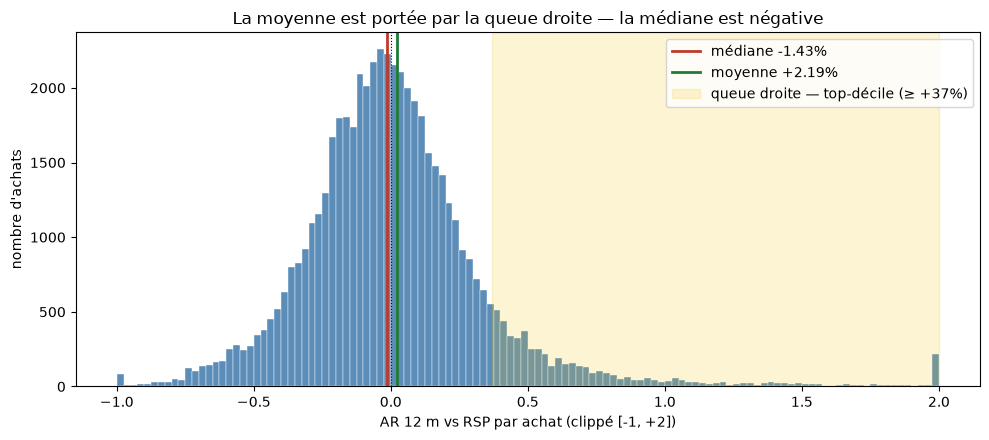

n = 54,130 | moyenne +2.19% | médiane -1.43% | seuil top-décile +36.85%


In [16]:
# Histogramme de car12 : moyenne (positive) vs médiane (négative), zone queue droite
car12 = buys['car12'].dropna()
moy, med = car12.mean(), car12.median()
q90 = car12.quantile(0.90)
clip = car12.clip(-1.0, 2.0)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(clip, bins=120, color='#5B8DB8', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='black', lw=0.8, ls=':')
ax.axvline(med, color='#C0392B', lw=2, label=f'médiane {med:+.2%}')
ax.axvline(moy, color='#1E7B34', lw=2, label=f'moyenne {moy:+.2%}')
ax.axvspan(q90, 2.0, color='#F1C40F', alpha=0.18,
           label=f'queue droite — top-décile (≥ {q90:+.0%})')
ax.set_xlabel("AR 12 m vs RSP par achat (clippé [-1, +2])")
ax.set_ylabel("nombre d'achats")
ax.set_title("La moyenne est portée par la queue droite — la médiane est négative")
ax.legend()
plt.tight_layout(); plt.show()

print(f"n = {len(car12):,} | moyenne {moy:+.2%} | médiane {med:+.2%} | seuil top-décile {q90:+.2%}")

**Lecture du graphe.**
- Médiane **négative** (**−1,43 %**) : l'achat typique sous-performe RSP sur 12 m.
- Moyenne **+2,19 %** tirée par la **queue droite**, pas représentative du trade central.
- **Loterie à queue droite** : beaucoup de petits perdants, quelques très gros gagnants.

### 2.3 D'où vient la moyenne ? Décomposition par le top-décile

- Part des **gains positifs** captée par le **top-décile** de `car12`, et moyenne **une fois ce top-décile retiré**.
- Seuil : `q90` = quantile 0,90 de `car12`.
- Si retirer 10 % fait basculer la moyenne en négatif → l'edge est dans la queue, pas dans un taux de réussite.

In [17]:
# Décomposition de la moyenne : poids du top-décile dans les gains, moyenne sans lui
c = buys['car12'].dropna()
srt = np.sort(c.values)[::-1]          # tri décroissant
k = len(srt) // 10                      # taille du top-décile
seuil = c.quantile(0.90)
part_top = srt[:k].sum() / c[c > 0].sum()   # part des gains positifs captée par le top-décile
moy_sans_top = srt[k:].mean()               # moyenne après retrait du top-décile
sk = c.skew()

print(f"Achats avec AR 12 m mesurable : {len(c):,}")
print(f"Seuil top-décile (q90 de car12)  : {seuil:+.2%}")
print(f"Part des GAINS positifs captée par le top-décile : {part_top:.0%}")
print(f"Moyenne SANS le top-décile        : {moy_sans_top:+.2%}")
print(f"Skewness de car12                 : {sk:.1f}")

Achats avec AR 12 m mesurable : 54,130
Seuil top-décile (q90 de car12)  : +36.85%
Part des GAINS positifs captée par le top-décile : 60%
Moyenne SANS le top-décile        : -6.52%
Skewness de car12                 : 14.0


**Lecture de la décomposition.**
- Le **top-décile** (CAR12 ≥ **+36,85 %**) capte **60 %** des gains positifs.
- Sans lui, la moyenne des 90 % restants tombe à **−6,52 %**.
- Skew **14,0** → on ne gagne que si on attrape les rares gros coups.

### Verdict 2 — loterie à queue droite
- 12 m vs RSP : moyenne **+2,19 %**, médiane **−1,43 %**, 47,5 % gagnants, skew **14,0**.
- vs SPY **−0,16 %**, vs secteur **+0,91 %** : médiane négative partout.
- Le **top-décile** capte **60 %** des gains ; sans lui, **−6,52 %**.

## 3. Où le signal se concentre (coupes)

L'edge agrégé (CAR 12 m vs RSP **+2,19 %**) est extrêmement asymétrique. On dissèque **où** il se loge.
- **Coupes** : chambre, parti, taille, durée, commission clé, timing → CAR 12 m.
- **Concentration** : dans le top-décile, quels tickers / secteurs / membres portent les gains.
- **Robustesse** : edge informationnel ou *beta de style* + quelques individus ? → placebo, résidualisation secteur×année, **t clusterisé**.

### 3.0 Méthode — la coupe ET le t honnête

Profil multi-métriques par coupe (calculé en 3.1) : **n**, **rdt brut** (`raw12`), **CAR vs RSP** (`car12`), **CAR vs secteur** (`car12_sec`), **hit rate**, **t naïf**, **t clusterisé**.

**Le t naïf surestime.** `t naïf = moyenne / (σ / √n)` suppose les CAR **indépendants**. Ils ne le sont pas :
- **Fenêtres chevauchantes** : achats du même mois sur titres corrélés → CAR corrélés.
- **Trades d'un même membre** : un membre qui achète 400× NVDA génère 400 CAR quasi-redondants → √n gonflé.

**Le t clusterisé par membre** corrige : on moyenne d'abord le CAR **par membre** (1 membre = 1 obs), puis `t = moy_membres / (σ_membres / √#membres)`. ~260 membres au lieu de ~46 000 achats → t honnête. **Arbitre retenu.**

### 3.1 Profil par coupe

- **Médianes-pivot** : taille `size_usd`, trades par membre, durée de détention.
- **Commission clé** : flag PIT `key_at(bio, year, keymap)`.
- **Timing** : entrée à `filed` (exploitable) vs `traded` (info non disponible, borne supérieure).

In [18]:
# socle commun aux 4 sous-sections : car12, flag key PIT, médianes-pivot
b = buys.dropna(subset=['car12']).copy()
b['key']  = [key_at(x, f.year, keymap) for x, f in zip(b['bioguide'], b['filed'])]
b['cham'] = b['chamber'].astype(str).str.lower()
b['par']  = b['party'].astype(str).str.upper().str[0]
b['hold'] = (b['exit_d'] - b['filed']).dt.days          # durée de détention (règle Ramify)
amed = b['size_usd'].median()
ntr  = b.groupby('bioguide')['car12'].transform('size')  # nb de trades du membre
nmed = b.groupby('bioguide').size().median()
hmed = b['hold'].median()
print(f'pivots — taille médiane {amed:,.0f}$ | trades/membre médian {nmed:.0f} | détention médiane {hmed:.0f} j')

# rendement brut 12 m (sans benchmark) et CAR vs secteur, par achat
def raw_col(sub):
    out=[]
    for t,f in zip(sub['ticker'],sub['filed']):
        if t not in panel.columns: out.append(np.nan); continue
        px=panel[t].dropna(); i=px.index.searchsorted(pd.Timestamp(f)); j=i+252
        out.append(px.iloc[j]/px.iloc[i]-1.0 if (i<len(px) and j<len(px) and px.iloc[i]>0) else np.nan)
    return np.array(out)
b['raw12']    = raw_col(b)
b['car12_sec']= abn_col(b, RSP, 252, use_sector=True)
# entrée datée 'traded' (borne sup. du signal, non exploitable en temps réel)
b['car12_traded'] = abn_col(b.assign(filed=b['traded']), RSP, 252)

pivots — taille médiane 8,000$ | trades/membre médian 38 | détention médiane 189 j


In [19]:
# t naïf vs t clusterisé par membre
def t_naif(s):
    s=s.dropna(); return s.mean()/(s.std(ddof=1)/np.sqrt(len(s))) if len(s)>1 else np.nan
def t_cluster(sub, col='car12'):
    m=sub.dropna(subset=[col]).groupby('bioguide')[col].mean().dropna()
    return m.mean()/(m.std(ddof=1)/np.sqrt(len(m))) if len(m)>=2 else np.nan
def hit(s):
    s=s.dropna(); return (s>0).mean() if len(s) else np.nan

COUPES=[('Sénat',b['cham'].eq('senate')),('House',b['cham'].eq('house')),
        ('Républicains',b['par'].eq('R')),('Démocrates',b['par'].eq('D')),
        ('Gros (>méd)',b['size_usd']>amed),('Petits (<=méd)',b['size_usd']<=amed),
        ('Prolifiques',ntr.values>nmed),('Rares',ntr.values<=nmed),
        ('Détent. courte',b['hold']<=hmed),('Détent. longue',b['hold']>hmed),
        ('Commission clé',b['key']),('Hors commission',~b['key']),
        ('Entrée=filed',pd.Series(True,index=b.index))]
rows=[]
for nm,msk in COUPES:
    sub=b[np.asarray(msk)]; s=sub['car12']
    rows.append({'coupe':nm,'n':int(s.notna().sum()),'#mem':int(sub.dropna(subset=['car12']).groupby('bioguide').ngroups),'raw12':sub['raw12'].mean(),
                 'CAR12':s.mean(),'CAR_sec':sub['car12_sec'].mean(),'hit':hit(s),
                 't_naïf':t_naif(s),'t_clust':t_cluster(sub)})
s_tr=b['car12_traded']
rows.append({'coupe':'Entrée=traded','n':int(s_tr.notna().sum()),'#mem':int(b.dropna(subset=['car12_traded']).groupby('bioguide').ngroups),'raw12':np.nan,
             'CAR12':s_tr.mean(),'CAR_sec':np.nan,'hit':hit(s_tr),
             't_naïf':t_naif(s_tr),'t_clust':t_cluster(b,'car12_traded')})
T31=pd.DataFrame(rows)
d=T31.copy()
for c in ['raw12','CAR12','CAR_sec','hit']: d[c]=d[c].map(lambda x:f'{x:+.2%}' if pd.notna(x) else '—')
for c in ['t_naïf','t_clust']: d[c]=d[c].map(lambda x:f'{x:+.2f}' if pd.notna(x) else '—')
print(d.to_string(index=False))

          coupe     n  #mem   raw12  CAR12 CAR_sec     hit t_naïf t_clust
          Sénat  4661    41 +18.54% +3.97%  +3.10% +49.50%  +7.69   +0.61
          House 49469   216 +14.21% +2.02%  +0.70% +47.32%  +9.15   +1.58
   Républicains 25985   142 +13.90% +1.70%  +0.53% +47.22%  +6.13   -1.03
     Démocrates 28131   112 +15.21% +2.64%  +1.26% +47.77%  +8.69   +2.82
    Gros (>méd) 13183   181 +13.08% +1.83%  +0.08% +48.94%  +5.11   -0.17
 Petits (<=méd) 40947   230 +15.07% +2.30%  +1.18% +47.05%  +9.31   +1.21
    Prolifiques 52798   126 +14.63% +2.22%  +0.96% +47.57% +10.60   +1.76
          Rares  1332   129 +12.83% +0.94%  -0.92% +45.12%  +0.76   +1.15
 Détent. courte 27104   166 +12.70% +1.37%  +0.02% +45.93%  +4.18   -0.90
 Détent. longue 27026   252 +16.48% +3.01%  +1.80% +49.09% +11.95   +1.70
 Commission clé 30871   113 +15.47% +3.47%  +1.78% +48.41% +11.33   +1.42
Hors commission 23259   176 +13.41% +0.49%  -0.25% +46.30%  +1.91   +1.52
   Entrée=filed 54130   255 +14.59% +2

**Lecture 3.1.**
- **Commission clé** : CAR 12 m **+3,47 %** vs **+0,49 %** hors.
- **Sénat** +3,97 % mais t_clust **+0,61** ; **House** +2,02 % (t_clust +1,58) ; **Démocrates** +2,64 % (t_clust **+2,82**) vs **Républicains** +1,70 % (t_clust **−1,03**).
- **Détention longue** +3,01 % (t_clust +1,70) ; **prolifiques** +2,22 % ≈ **rares** +0,94 %.
- **Effondrement naïf→clusterisé** : commission clé **+11,33 → +1,42** ; Républicains signe inversé. Peu d'individus portent le résultat.
- **Timing** : `traded` +1,88 % ≈ `filed` +2,19 % — la latence ne détruit pas le signal.

### 3.2 Concentration ticker & secteur

- **Top-décile** : `car12 >= quantile 0,90` (les « jackpots »).
- Par **ticker** et **secteur GICS** : nombre de jackpots, CAR moyen, **part des gains positifs totaux**.
- Si une poignée de noms tech monopolise → edge concentré, pas diffus.

In [20]:
q90=b['car12'].quantile(0.90); top=b[b['car12']>=q90]; tot_pos=b.loc[b['car12']>0,'car12'].sum()
print(f'top-décile : car12 >= {q90:+.1%} | {len(top):,} achats')
tk=top.groupby('ticker').agg(jackpots=('car12','size'),CAR_moy=('car12','mean'),gains=('car12','sum'))
tk['part_gains']=tk['gains']/tot_pos; tk=tk.sort_values('gains',ascending=False).head(10)
dt=tk.copy(); dt['CAR_moy']=dt['CAR_moy'].map('{:+.0%}'.format); dt['part_gains']=dt['part_gains'].map('{:.1%}'.format)
print('\nTICKERS (top-décile) :'); print(dt.drop(columns='gains').to_string())
sec=top.dropna(subset=['sector_gics']).groupby('sector_gics').agg(jackpots=('car12','size'),CAR_moy=('car12','mean'),gains=('car12','sum'))
sec['part_gains']=sec['gains']/tot_pos; sec=sec.sort_values('gains',ascending=False).head(6)
ds=sec.copy(); ds['CAR_moy']=ds['CAR_moy'].map('{:+.0%}'.format); ds['part_gains']=ds['part_gains'].map('{:.1%}'.format)
print('\nSECTEURS (top-décile) :'); print(ds.drop(columns='gains').to_string())
print(f"\nNVDA seul = {tk['part_gains'].iloc[0]:.1%} des gains positifs | top-10 tickers = {tk['part_gains'].sum():.1%}")

top-décile : car12 >= +36.8% | 5,413 achats

TICKERS (top-décile) :
        jackpots CAR_moy part_gains
ticker                             
NVDA         175   +118%       2.8%
SNDK           9  +1527%       1.9%
DAIUF          9  +1377%       1.7%
MU            43   +231%       1.4%
AMZN         140    +58%       1.1%
META          66    +98%       0.9%
URBN          57   +108%       0.8%
PSKY          27   +218%       0.8%
NFLX          69    +79%       0.7%
AAPL          91    +59%       0.7%

SECTEURS (top-décile) :
                        jackpots CAR_moy part_gains
sector_gics                                        
Information Technology      1518    +99%      20.6%
Industrials                  643    +91%       8.1%
Consumer Discretionary       743    +73%       7.4%
Health Care                  596    +65%       5.3%
Communication Services       421    +90%       5.2%
Financials                   548    +63%       4.7%

NVDA seul = 2.8% des gains positifs | top-10 tickers = 12.

**Lecture 3.2.**
- **NVDA seul** = **2,8 %** des gains (175 jackpots, CAR moyen +118 %) ; **top-10 tickers = 12,9 %**.
- Micro-caps (SNDK +1527 %, DAIUF +1377 %) = situations spéciales, non réplicables.
- **Information Technology** = **20,6 %** des gains (1518 jackpots) → **pari tech**.

### 3.3 Concentration membre

- Par membre avec **≥ 30 achats** : CAR 12 m moyen, jackpots placés (top-décile), **part des jackpots totaux**.
- On regarde le **top** et le **bottom** par CAR moyen, et **qui place le plus de jackpots**.

In [21]:
gm=b.groupby('bioguide').agg(name=('name','first'),n=('car12','size'),CAR_moy=('car12','mean'),
                            jack=('car12',lambda s:(s>=q90).sum()))
gm=gm[gm['n']>=30]; gm['part_jack']=gm['jack']/len(top)
print(f'membres avec >=30 achats : {len(gm)}')
def show(g):
    d=g.copy(); d['CAR_moy']=d['CAR_moy'].map('{:+.1%}'.format); d['part_jack']=d['part_jack'].map('{:.1%}'.format)
    print(d[['name','n','CAR_moy','jack','part_jack']].to_string())
print('\nTOP CAR moyen :');   show(gm.sort_values('CAR_moy',ascending=False).head(8))
print('\nBOTTOM CAR moyen :');show(gm.sort_values('CAR_moy').head(8))
jm=gm.sort_values('jack',ascending=False).head(8)
print('\nPLUS de jackpots :');show(jm)
print(f"\ntop-8 placeurs de jackpots = {jm['part_jack'].sum():.1%} des jackpots | Khanna seul = {jm['part_jack'].iloc[0]:.1%}")

membres avec >=30 achats : 137

TOP CAR moyen :
                              name    n CAR_moy  jack part_jack
bioguide                                                       
S001198          Daniel S Sullivan   35  +57.9%    21      0.4%
B001292      Donald Sternoff Beyer  358  +51.9%    74      1.4%
W000797   Debbie Wasserman Schultz   40  +29.6%    18      0.3%
G000590                 Mark Green  256  +20.3%    70      1.3%
D000598             Susan A. Davis   32  +16.6%     8      0.1%
G000596     Marjorie Taylor Greene  431  +16.5%    96      1.8%
M001198          Roger W. Marshall   55  +14.9%    17      0.3%
M001190           Markwayne Mullin  200  +14.2%    38      0.7%

BOTTOM CAR moyen :
                           name    n CAR_moy  jack part_jack
bioguide                                                    
B001299          James E. Banks   30  -31.5%     5      0.1%
S001189            Austin Scott   38  -30.4%     3      0.1%
N000192            Marie Newman  127  -26.8%    

**Lecture 3.3.**
- **8 placeurs = 59,9 %** des jackpots ; **Khanna seul 30,8 %** (1665), mais CAR moyen **+2,4 %** (tech par construction, pas sélection).
- Meilleurs CAR moyens rares : Sullivan +57,9 % (35), Beyer +51,9 % (358), Greene +16,5 % (431).
- Bottom : Banks −31,5 %, Austin Scott −30,4 %, Newman −26,8 %.

### 3.4 Robustesse — edge informationnel, ou beta + quelques personnes ?

Trois tests adverses.

- **(a) Placebo achats vs ventes** : si le signal est directionnel, les grosses **ventes** devraient sous-performer. Si gros achats ET grosses ventes montent pareil → **tilt de style**, pas de direction.
- **(b) Commission clé résidualisée** : key vs hors par **Welch t**, sur CAR brut puis **résidualisé secteur×année**. Si l'écart survit → pas qu'un effet « plus de tech en bonne année ».
- **(c) Clustering** : t naïf vs t clusterisé pour « ≥ 250 k$ » et « commission clé ».

In [22]:
# (a) PLACEBO : gros achats vs grosses ventes (top-décile de taille de chaque côté)
big_buys=b[b['size_usd']>b['size_usd'].quantile(0.90)]['car12'].dropna()
sl=df[(df['op']=='sell')&df['ticker'].notna()].copy(); sl['size_usd']=pd.to_numeric(sl['size_usd'],errors='coerce')
big_sells=sl[sl['size_usd']>sl['size_usd'].quantile(0.90)]
cs=abn_col(big_sells,RSP,252); cs=cs[~np.isnan(cs)]
print(f'(a) gros ACHATS  CAR12 {big_buys.mean():+.2%} (n={len(big_buys):,})')
print(f'    grosses VENTES CAR12 {cs.mean():+.2%} (n={len(cs):,})  -> les deux montent => tilt de style')

# (b) commission clé : Welch t brut puis résidualisé secteur x année
bb=b.dropna(subset=['car12','sector_gics']).copy(); bb['yr']=bb['filed'].dt.year
bb['resid']=bb['car12']-bb.groupby(['sector_gics','yr'])['car12'].transform('mean')
k=bb[bb['key']]; h=bb[~bb['key']]
wb=stats.ttest_ind(k['car12'],h['car12'],equal_var=False); wr=stats.ttest_ind(k['resid'],h['resid'],equal_var=False)
print(f"\n(b) Welch key vs hors  BRUT  diff {k['car12'].mean()-h['car12'].mean():+.2%}  t={wb.statistic:+.2f}")
print(f"                       RÉSID diff {k['resid'].mean()-h['resid'].mean():+.2%}  t={wr.statistic:+.2f}")

# (c) clustering sur les deux coupes vedettes
print()
for nm,sub in [('>=250k$',b[b['size_usd']>=250000]),('Commission clé',b[b['key']])]:
    print(f'(c) {nm:14s} n={len(sub):6,d}  t_naïf {t_naif(sub["car12"]):+.2f}  ->  t_clust {t_cluster(sub):+.2f}')

(a) gros ACHATS  CAR12 +2.39% (n=3,930)
    grosses VENTES CAR12 +3.40% (n=5,041)  -> les deux montent => tilt de style

(b) Welch key vs hors  BRUT  diff +2.85%  t=+6.94
                       RÉSID diff +2.21%  t=+5.58

(c) >=250k$        n=   740  t_naïf +1.59  ->  t_clust -0.33
(c) Commission clé n=30,871  t_naïf +11.33  ->  t_clust +1.42


**Lecture 3.4.**
- **(a) Placebo** : gros achats **+2,39 %** ≈ grosses ventes **+3,40 %** → **tilt de style**, pas de direction.
- **(b) Commission clé survit** à la résidualisation : Welch brut diff **+2,85 %** (t +6,94), résidualisé **+2,21 %** (t +5,58).
- **(c) Clustering = couperet** : « ≥ 250 k$ » t **+1,59 → −0,33** ; « commission clé » **+11,33 → +1,42**.

### Verdict 3 — où chercher, et ce qui s'évapore
- **Meilleur découpage = commission clé** : +3,47 % vs +0,49 %, seul à survivre à la résidualisation (Welch t +5,58).
- **Concentration extrême** : NVDA 2,8 % des gains, IT 20,6 % ; 8 membres = 59,9 % des jackpots (Khanna 30,8 %).
- **Tout s'évapore au clustering** : commission +11,33 → +1,42 ; « ≥ 250 k$ » +1,59 → −0,33 ; Républicains signe inversé.
- **Placebo** : achats ≈ ventes → **beta de style (tech)**, pas de la direction. → tester en portefeuille (Partie 4).

## 4. Backtest rigoureux — suivre TOUT le Congrès

- **Question** : **copier tous les achats**, sans sélection — le signal brut agrégé contient-il de l'alpha, ou seulement du bêta ?
- **Mécanisme (identique partout)** :
  - *Entrée* : `filed + 1` jour (`lag_days=1`).
  - *Sortie* : vente déclarée du même membre/titre, sinon **+12 mois** (`horizon_months=12`).
  - *Coûts* : **20 bps** (`cost_bps=20`) par variation de poids.
  - *Rendements* : journaliers, **winsorisés à ±50 %**.
- **Hypothèses** : pas de slippage au-delà des 20 bps, exécution au close, capital pleinement investi.

### 4.1 Variantes « copier tout » : CAGR / vol / Sharpe / maxDD

- **Trois pondérations** : `equal` (1/n), `size` (∝ `size_usd`), `sqrt_size` (∝ √`size_usd`).
- **Métriques** (annualisées, `ann_stats`) : *CAGR* = (∏(1+r))^(252/jours) −1 ; *vol* = σ × √252 ; *Sharpe* = (moyenne/σ) × √252 (brut de RF) ; *maxDD* = pire perte crête-creux.
- **Benchmarks** : `SPY`, `RSP` (le bon comparable, équi-pondéré), `60/40` = 0,6·SPY + 0,4·AGG.

In [23]:
# 4.1 — trois variantes « copier tout » vs benchmarks
WEIGHTINGS = ['equal', 'size', 'sqrt_size']
pos_all = build_positions(buys, df, horizon_months=12, sell_map=SELL_MAP)
nets = {w: run_portfolio(pos_all, panel, w, cost_bps=20, lag_days=1)['net'] for w in WEIGHTINGS}
ref_idx = nets['size'].index

# benchmarks alignés sur la fenêtre du portefeuille (60/40 = 0,6·SPY + 0,4·AGG)
spy_d = bench_daily(SPY, ref_idx)
rsp_d = bench_daily(RSP, ref_idx)
agg_d = bench_daily(etfp['AGG'], ref_idx)
b6040_d = 0.6 * spy_d + 0.4 * agg_d

series_4_1 = {**{f'copier-tout · {w}': nets[w] for w in WEIGHTINGS},
              'SPY': spy_d, 'RSP': rsp_d, '60/40': b6040_d}

tab41 = pd.DataFrame([{'CAGR': ann_stats(d)['CAGR'], 'vol': ann_stats(d)['vol'],
                       'Sharpe': ann_stats(d)['sharpe'], 'maxDD': ann_stats(d)['maxDD']}
                      for d in series_4_1.values()], index=list(series_4_1)).rename_axis('stratégie')
_F41 = {'CAGR': '{:+.2%}'.format, 'vol': '{:.2%}'.format, 'Sharpe': '{:.2f}'.format, 'maxDD': '{:.2%}'.format}
print(tab41.to_string(formatters=_F41))

                           CAGR    vol Sharpe   maxDD
stratégie                                            
copier-tout · equal      +9.68% 16.27%   0.65 -36.75%
copier-tout · size      +10.65% 17.20%   0.68 -33.10%
copier-tout · sqrt_size  +9.85% 16.38%   0.66 -36.36%
SPY                     +14.96% 16.58%   0.92 -33.72%
RSP                     +12.94% 17.04%   0.80 -39.04%
60/40                    +9.95% 10.28%   0.97 -21.72%


**Lecture 4.1.**
- Meilleure variante `size` : **CAGR +10,65 %, Sharpe 0,68, maxDD −33,10 %** ; `equal` 0,65, `sqrt_size` 0,66.
- **Aucune ne bat SPY** : **CAGR +14,96 %, Sharpe 0,92** ; RSP 0,80 ; 60/40 Sharpe 0,97 (vol 10,3 %).
- Sharpe sous SPY + vol élevée → portefeuille essentiellement **bêta**.

### 4.2 Famille ALPHA : bêta ou alpha ?

- On régresse le rendement excédentaire (`r − RF`) de chaque variante sur les facteurs ; ce qu'ils n'expliquent pas = l'intercept α.
- **Trois modèles** (`factor_alpha`, HAC Newey-West 5 lags) : *CAPM* (`Mkt-RF`), *FF3* (+`SMB`+`HML`), *FFC4* (+`Mom`).
- Symboles : rₜ−RF = α + β·(Mkt-RF) + … + εₜ ; α = sur-rendement annualisé inexpliqué ; β = sensibilité marché ; t = α/σ(α) ; R² = variance expliquée.
- **Lecture** : α compte seulement si **|t| ≥ 2** ; β ≈ 1 + R² élevé = « marché déguisé ». Le t (pas le signe de α) tranche.

In [24]:
# 4.2 — alpha CAPM / FF3 / FFC4 (t HAC), bêta marché, R²
tab42 = pd.DataFrame([{
    'variante': w,
    'aCAPM': factor_alpha(nets[w], factors, 'capm')['alpha_annuel'],
    'tCAPM': factor_alpha(nets[w], factors, 'capm')['alpha_t'],
    'aFF3':  factor_alpha(nets[w], factors, 'ff3')['alpha_annuel'],
    'tFF3':  factor_alpha(nets[w], factors, 'ff3')['alpha_t'],
    'aFFC4': factor_alpha(nets[w], factors, 'ffc4')['alpha_annuel'],
    'tFFC4': factor_alpha(nets[w], factors, 'ffc4')['alpha_t'],
    'beta':  factor_alpha(nets[w], factors, 'ffc4')['beta_marche'],
    'tbeta': factor_alpha(nets[w], factors, 'ffc4')['beta_t'],
    'R2':    factor_alpha(nets[w], factors, 'ffc4')['R2'],
} for w in WEIGHTINGS]).set_index('variante')
_F42 = {c: ('{:+.2%}'.format if c.startswith('a') else ('{:+.2f}'.format if c.startswith('t') else '{:.2f}'.format))
        for c in tab42.columns}
print(tab42.to_string(formatters=_F42))

           aCAPM tCAPM   aFF3  tFF3  aFFC4 tFFC4 beta  tbeta   R2
variante                                                         
equal     -3.33% -2.42 -2.83% -2.46 -2.25% -2.09 0.91 +81.42 0.95
size      -2.61% -1.76 -2.32% -1.59 -2.05% -1.42 0.96 +67.30 0.91
sqrt_size -3.22% -2.43 -2.76% -2.42 -2.22% -2.07 0.92 +89.44 0.95


**Lecture 4.2.**
- **β marché plein** : 0,91–0,96 (t +67 à +89), R² **0,91–0,95**. Le portefeuille *est* le marché.
- **Alphas NÉGATIFS**, certains significatifs : `equal` aCAPM **−3,33 % (t −2,42)**, FFC4 **−2,25 % (t −2,09)** ; `sqrt_size` FFC4 **−2,22 % (t −2,07)** ; `size` aCAPM −2,61 % (t −1,76).
- Non seulement **pas d'alpha** — copier tout **détruit** de la valeur nette du marché.

### 4.3 Famille SHARPE : qualité du risque ajusté

- Quatre angles : *Sharpe* = (moy/σ)·√252 ; *PSR* (prob. vrai Sharpe > 0, corrige asymétrie/kurtosis) ; *Sortino* = (moy/σ des jours négatifs)·√252 ; *IR vs RSP* = moyenne(r−RSP)/σ(r−RSP)·√252.
- **PSR vs DSR** : le **PSR** compare le Sharpe à **zéro** ; le **DSR** (Deflated) au **meilleur Sharpe attendu par hasard sur *n* essais**. Un PSR ≈ 1 ne dit rien sur le data-mining. DSR non calculable ici (1 stratégie/ligne) → **Partie 5.4** (44 essais).

In [25]:
# 4.3 — Sharpe / PSR / Sortino / IR vs RSP (variantes + SPY + RSP)
sharpe_set = {**{w: nets[w] for w in WEIGHTINGS}, 'SPY': spy_d, 'RSP': rsp_d}
tab43 = pd.DataFrame([{'Sharpe': sharpe(d), 'PSR': psr(d), 'Sortino': sortino(d),
                       'IR_vs_RSP': info_ratio(d, rsp_d)}
                      for d in sharpe_set.values()], index=list(sharpe_set)).rename_axis('stratégie')
_F43 = {'Sharpe': '{:.2f}'.format, 'PSR': '{:.2f}'.format, 'Sortino': '{:.2f}'.format, 'IR_vs_RSP': '{:+.2f}'.format}
print(tab43.to_string(formatters=_F43))

          Sharpe  PSR Sortino IR_vs_RSP
stratégie                              
equal       0.65 0.99    0.75     -0.53
size        0.68 0.99    0.79     -0.24
sqrt_size   0.66 0.99    0.76     -0.47
SPY         0.92 1.00    1.14     +0.31
RSP         0.80 1.00    1.00       NaN


**Lecture 4.3.**
- **SPY domine** : Sharpe **0,92**, Sortino 1,14, IR vs RSP +0,31.
- Variantes Congrès : Sharpe 0,65–0,68, **IR vs RSP tous négatifs** (−0,24 à −0,53).
- PSR ≈ 0,99 (Sharpe positif quasi certain), mais **aucune ne domine SPY**.

### 4.4 Test GRS joint : tous les alphas sont-ils nuls *ensemble* ?

- **Pourquoi** : les 4.2 testent les alphas un par un ; le **GRS** les teste **conjointement**, en contrôlant leur corrélation et le data-mining.
- **H0** : α₁ = … = αₙ = 0 (les facteurs FFC4 expliquent entièrement les portefeuilles).
- **Portefeuilles NON CHEVAUCHANTS** : partition **2×2** chambre × commission ({House, Sénat} × {clé, non-clé}) → disjoints (Σ résiduel inversible). Robustesse : variante « 3 pondérations ».
- **Construction** (`grs_test`) : rendements **mensuels excédentaires** (resample 'ME'), facteurs composés au mois.
- **Statistique** : GRS ~ **F(N, T−N−L)** ; N = portefeuilles, T = mois, L = facteurs.
- **Lecture** : **p < 0,05 → rejet de H0** (alpha existe) ; **p ≥ 0,05 → compatible avec « tout est bêta »** (absence de preuve, pas preuve d'absence).

In [26]:
# 4.4 — GRS sur partition 2x2 NON chevauchante : chambre x {clé, non-clé}
b = buys.copy()
b['key'] = [key_at(x, f.year, keymap) for x, f in zip(b['bioguide'], b['filed'])]
b['cham'] = b['chamber'].str.lower()
test_defs = {
    'House·clé':      (b['cham'].eq('house'))  & (b['key']),
    'House·non-clé':  (b['cham'].eq('house'))  & (~b['key']),
    'Sénat·clé':      (b['cham'].eq('senate')) & (b['key']),
    'Sénat·non-clé':  (b['cham'].eq('senate')) & (~b['key']),
}

def monthly_excess(daily, rf_m):
    m = (1 + daily).resample('ME').prod() - 1
    return m - rf_m.reindex(m.index)

rf_m = (1 + factors['RF']).resample('ME').prod() - 1
Fm = pd.DataFrame({c: (1 + factors[c]).resample('ME').prod() - 1 for c in ['Mkt-RF', 'SMB', 'HML', 'Mom']})

cols = {nm: monthly_excess(
            run_portfolio(build_positions(b[mask], df, 12, sell_map=SELL_MAP), panel, 'size', 20)['net'], rf_m)
        for nm, mask in test_defs.items()}
R = pd.DataFrame(cols).dropna()
res = grs_test(R, Fm)
print('Partition 2x2 (chambre x clé) : '
      f"GRS={res['GRS']:.3f}  p={res['p_value']:.3f}  N={res['N']}  T={res['T']}  L={res['L']}  (loi F à {res['N']},{res['T']-res['N']-res['L']} ddl)")

# robustesse : les 3 variantes de pondération comme portefeuilles-test
cols2 = {w: monthly_excess(nets[w], rf_m) for w in WEIGHTINGS}
res2 = grs_test(pd.DataFrame(cols2).dropna(), Fm)
print('Robustesse 3-pondérations    : '
      f"GRS={res2['GRS']:.3f}  p={res2['p_value']:.3f}  N={res2['N']}  T={res2['T']}  L={res2['L']}  (loi F à {res2['N']},{res2['T']-res2['N']-res2['L']} ddl)")

Partition 2x2 (chambre x clé) : GRS=1.386  p=0.241  N=4  T=160  L=4  (loi F à 4,152 ddl)
Robustesse 3-pondérations    : GRS=1.278  p=0.284  N=3  T=160  L=4  (loi F à 3,153 ddl)


**Lecture 4.4.**
- 2×2 (N=4, T=160) : **GRS 1,386, p 0,241**. 3-pondérations : **GRS 1,278, p 0,284**.
- **p ≫ 0,05 → on NE rejette PAS H0** : aucun alpha conjoint (cohérent avec les alphas nuls/négatifs de 4.2).

### 4.5 Courbes d'équité (échelle log)

- Valeur composée nette des trois variantes vs SPY et RSP, base 1.
- **Échelle log** : pente égale = même rendement composé ; on lit la *forme* (drawdowns 2020, 2022).

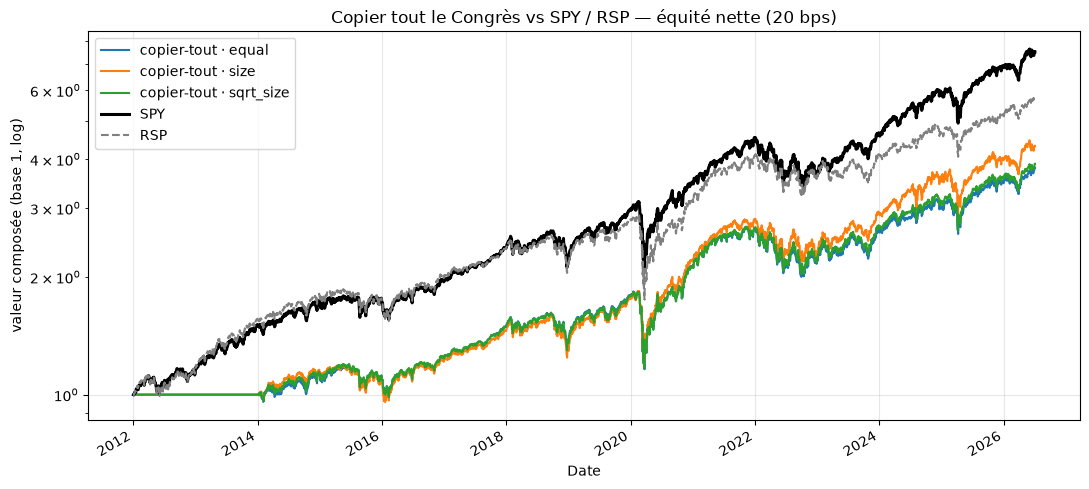

In [27]:
# 4.5 — equity curves nettes vs SPY / RSP (échelle log)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 5))
for w in WEIGHTINGS:
    (1 + nets[w]).cumprod().plot(ax=ax, label=f'copier-tout · {w}')
(1 + spy_d).cumprod().plot(ax=ax, label='SPY', lw=2.2, color='black')
(1 + rsp_d).cumprod().plot(ax=ax, label='RSP', lw=1.5, color='grey', ls='--')
ax.set_yscale('log')
ax.set_ylabel('valeur composée (base 1, log)')
ax.set_title('Copier tout le Congrès vs SPY / RSP — équité nette (20 bps)')
ax.legend(loc='upper left'); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Lecture 4.5.**
- Les trois courbes suivent SPY de près (**β 0,91–0,96 / R² ≥ 0,91**).
- `size` (la meilleure) reste **sous SPY** sur toute la fenêtre ; creux communs (Covid 2020, taux 2022).

### Verdict — Partie 4
- **« Copier tout » ≈ détenir le marché** : β 0,91–0,96 (t +67 à +89), R² ≥ 0,91.
- **Alphas FFC4 négatifs**, certains significatifs (`equal` −2,25 % t −2,09, `sqrt_size` −2,22 % t −2,07) → destruction de valeur nette du marché.
- **Rien ne bat SPY** : Sharpe SPY **0,92** > toutes les variantes (0,65–0,68).
- **GRS ne rejette pas H0** (p 0,24 / 0,28). → il faut un sous-ensemble **CIBLÉ** (Partie 5).

## 5. La sélection : 11 critères en walk-forward strict

- **Problème Ramify** : **choisir K membres** dont on réplique les achats l'année suivante. Règles :
  - classement des membres **en fin d'année N** sur un critère ;
  - **éligible** = **≥ 10 trades clôturés** ;
  - **≥ moitié** du panier en **commission clé** (contrainte d'information, PIT) ;
  - positions laissées courir (vente déclarée, sinon 12 mois).
- **Walk-forward strict (zéro look-ahead)** : sélection sur trades à **sortie ≤ 31/12 de N** (`exit_d`), appliquée aux achats **filés en N+1** (`gate_buys` décale d'un an).
- **Questions** : quel critère sélectionne le mieux ? le gain survit-il au choix de K, au **Deflated Sharpe** (essais multiples) et à la **persistance** ?

### 5.1 Les 11 critères de sélection

Notation. Pour un membre : $a_1,\dots,a_n$ = rendements **anormaux réalisés** (vs RSP, `tret`), $r_1,\dots,r_n$ = rendements **bruts** (`traw`), $n$ = trades clôturés, $N$ = total de trades du groupe éligible, $\bar S$ = Sharpe moyen du groupe. *Supposé* : trades i.i.d. (faux → t-stats optimistes) ; le passé réalisé informe le futur (l'hypothèse testée).

- **c1 — hit rate** : $\frac1n\sum \mathbb 1[a_i>0]$. Régularité. *Faiblesse* : ignore la taille des gains/pertes.
- **c2 — rendement brut moyen** : $\frac1n\sum r_i$. *Faiblesse* : capte surtout le **bêta**.
- **c3 — rendement anormal moyen** : $\frac1n\sum a_i$. Skill net du marché. *Faiblesse* : dominé par les outliers de queue.
- **c4 — médiane de l'anormal** : $\mathrm{med}(a_i)$. Skill **robuste**. *Faiblesse* : jette la queue, où vit l'alpha.
- **c5 — profit factor** : $\sum_{a_i>0} a_i \big/ \big|\sum_{a_i\le 0} a_i\big|$ (plafonné à 10). >1 = profitable. *Faiblesse* : instable sur petit $n$.
- **c6 — Sharpe des trades** : $\bar a/\sigma_a$. *Faiblesse* : énorme erreur d'estimation sur 10–20 trades.
- **c7 — Shrunk Sharpe (Mauboussin)** : $\frac{n}{n+k}\,\frac{\bar a}{\sigma_a} + \big(1-\frac{n}{n+k}\big)\bar S$ ($k{=}10$). Dégonfle vers le groupe. *Faiblesse* : $k$ arbitraire.
- **c8 — UCB (*Upper Confidence Bound*, bandits Sutton-Barto) — critère « officiel »** : $c7 + c\sqrt{\ln N / n}$ ($c{=}0{,}5$). Shrunk Sharpe + bonus d'exploration (optimisme face à l'incertitude). *Faiblesse* : le bonus peut remonter du bruit.
- **c9 — t-stat du membre** : $\bar a/(\sigma_a/\sqrt n)$. Skill crédible. *Faiblesse* : t naïf (pas de correction clustering).
- **c10 — α CAPM** : ordonnée $\alpha$ de $R^e_t = \alpha + \beta\,\mathrm{Mkt}^e_t + \varepsilon_t$ (annualisée, HAC). *Faiblesse* : un seul facteur → confond style et skill.
- **c11 — α FFC4** : $\alpha$ de la régression Carhart (4 facteurs). Le plus exigeant. *Faiblesse* : sur-paramétré sur une courte série d'un seul membre → très bruité.
- **Score total** = **moyenne des rangs** (percentiles) sur les critères risque-ajustés (c3, c6, c7, c9, c10). On **combine** au lieu de choisir un critère unique.
- **Contrainte commission clé (PIT)** : panier **≥ 50 % de membres en commission clé** à la date de sélection (`key_at`).

### 5.2 Scoreboard — une fiche de notes par membre

- Série quotidienne nette par membre (`build_all_member_series`) pour c10/c11.
- Tableau **arrêté fin 2022** (`member_scores(..., 2022, ...)`) : une ligne par membre éligible, 11 colonnes.
- On affiche le **top 6** trié par c8 (UCB), + comptes d'éligibilité.

In [28]:
# Serie quotidienne nette par membre (>=10 trades), puis scoreboard arrete fin 2022
member_daily = build_all_member_series(buys, df, panel)
sc22 = member_scores(buys, 2022, keymap, member_daily, factors)
n_elig = len(sc22); n_key = int(sc22['key'].sum())
print(f"membres notes (serie quotidienne, >=10 trades) : {len(member_daily)}")
print(f"fin 2022 -> eligibles : {n_elig} | dont commission cle : {n_key} ({n_key/n_elig:.0%})")

top6 = sc22.sort_values('c8_ucb', ascending=False).head(6)
show = top6[['name', 'n', 'key'] + CRITERIA].copy()
fmts = {'c1_hit':'{:.0%}'.format, 'c2_raw':'{:+.1%}'.format, 'c3_abn':'{:+.1%}'.format,
        'c4_med':'{:+.1%}'.format, 'c5_pf':'{:.2f}'.format, 'c6_sharpe':'{:.2f}'.format,
        'c7_shrunk':'{:.2f}'.format, 'c8_ucb':'{:.2f}'.format, 'c9_t':'{:+.2f}'.format,
        'c10_aCAPM':'{:+.1%}'.format, 'c11_aFFC4':'{:+.1%}'.format}
print('\nTop 6 fin 2022 (trie c8_ucb) :')
print(show.to_string(index=False, formatters=fmts))

membres notes (serie quotidienne, >=10 trades) : 192
fin 2022 -> eligibles : 142 | dont commission cle : 42 (30%)

Top 6 fin 2022 (trie c8_ucb) :
                   name  n   key c1_hit c2_raw c3_abn c4_med c5_pf c6_sharpe c7_shrunk c8_ucb  c9_t c10_aCAPM c11_aFFC4
           Justin Amash 18 False    67% +31.7% +12.3%  +7.0%  8.38      0.59      0.37   0.76 +2.48     +5.0%     +5.6%
      Frank A. LoBiondo 18 False    72% +22.8% +10.2%  +6.4%  6.15      0.57      0.36   0.74 +2.41     +5.3%     +5.2%
         Michael Garcia 15 False    87% +27.5% +23.0%  +3.1%  9.52      0.49      0.29   0.71 +1.88     -0.1%     +1.3%
Brenda Lulenar Lawrence 15 False    60% +65.1% +57.5% +28.3%  4.83      0.48      0.28   0.70 +1.87     +4.5%     +4.2%
   David Cheston Rouzer 13 False    62% +45.2% +28.7%  +0.4%  6.38      0.43      0.24   0.69 +1.57     +0.3%     +1.0%
           Cheri Bustos 15 False    53% +19.3% +11.3%  +1.4%  3.95      0.44      0.26   0.68 +1.71     +1.6%     +1.2%


### 5.3 Le grand tableau comparatif (walk-forward, K=6)

- Scoreboards de **chaque année 2014→2025** (`sc_cache`) pré-calculés.
- Pour **chacun des 11 critères** : sélection K=6 sur N → application N+1 → portefeuille net (pondéré taille, 20 bps).
- Une **ligne par critère** : positions, CAGR, vol, Sharpe, maxDD, α vs RSP, α CAPM (t), α FFC4 (t), bêta. Comparatif : **Sharpe de SPY**.

In [29]:
# Scoreboards par annee (cache) + moteur walk-forward identique pour les 11 criteres
sc_cache = {y: member_scores(buys, y, keymap, member_daily, factors) for y in range(2014, 2026)}

def wf_run(col, K=6, weighting='size'):
    sel = {y: (select_K(sc_cache[y], K, col) if len(sc_cache[y]) else []) for y in range(2014, 2026)}
    gb = gate_buys(buys, sel)
    if not len(gb): return None
    res = run_portfolio(build_positions(gb, df, 12, sell_map=SELL_MAP), panel, weighting, 20)
    net = res['net']; st = ann_stats(net)
    capm = factor_alpha(net, factors, 'capm'); ffc4 = factor_alpha(net, factors, 'ffc4')
    cagr_rsp = ann_stats(bench_daily(RSP, net.index))['CAGR']
    return {'n_pos': res['n_positions'], 'CAGR': st['CAGR'], 'vol': st['vol'], 'sharpe': st['sharpe'],
            'maxDD': st['maxDD'], 'a_rsp': st['CAGR']-cagr_rsp, 'aCAPM': capm['alpha_annuel'],
            'aCAPM_t': capm['alpha_t'], 'aFFC4': ffc4['alpha_annuel'], 'aFFC4_t': ffc4['alpha_t'],
            'beta': ffc4['beta_marche'], 'net': net}

# score total composite = moyenne des rangs (percentiles) sur les criteres risque-ajustes
RANKCOLS = ['c3_abn', 'c6_sharpe', 'c7_shrunk', 'c9_t', 'c10_aCAPM']
for _y, _sc in sc_cache.items():
    if len(_sc): _sc['c_total'] = _sc[RANKCOLS].rank(pct=True).mean(axis=1)
rows = {c: wf_run(c, K=6) for c in CRITERIA}
rows['c_total'] = wf_run('c_total', K=6)  # ligne supplementaire (hors 11 criteres officiels)
tbl = pd.DataFrame(rows).T
spy_sh = sharpe(bench_daily(SPY, rows['c1_hit']['net'].index))

disp = tbl[['n_pos','CAGR','vol','sharpe','maxDD','a_rsp','aCAPM','aCAPM_t','aFFC4','aFFC4_t','beta']]
fmt2 = {'n_pos':'{:.0f}'.format,'CAGR':'{:+.1%}'.format,'vol':'{:.1%}'.format,'sharpe':'{:.2f}'.format,
        'maxDD':'{:.1%}'.format,'a_rsp':'{:+.1%}'.format,'aCAPM':'{:+.1%}'.format,'aCAPM_t':'{:+.2f}'.format,
        'aFFC4':'{:+.1%}'.format,'aFFC4_t':'{:+.2f}'.format,'beta':'{:.2f}'.format}
print(disp.to_string(formatters=fmt2))
best = tbl.loc[CRITERIA, 'sharpe'].idxmax()  # meilleur parmi les 11 criteres officiels (le composite est diagnostic)
print(f"\nSPY Sharpe (memes dates) : {spy_sh:.2f}")
print(f"meilleur Sharpe : {best} = {tbl.loc[best,'sharpe']:.2f} | c11 sur-apprend : Sharpe {tbl.loc['c11_aFFC4','sharpe']:.2f}, aFFC4 {tbl.loc['c11_aFFC4','aFFC4']:+.1%}")

          n_pos    CAGR    vol sharpe   maxDD   a_rsp   aCAPM aCAPM_t   aFFC4 aFFC4_t  beta
c1_hit     1338   +6.8%  17.7%   0.46  -38.2%   -6.2%   -4.4%   -1.45   -3.1%   -1.07  0.82
c2_raw     1452  +12.2%  21.4%   0.65  -51.5%   -0.7%   +2.7%   +0.52   +2.7%   +0.53  0.77
c3_abn     1596   +7.1%  23.3%   0.41  -61.6%   -5.9%   -1.9%   -0.33   -1.4%   -0.24  0.78
c4_med     1524   +9.7%  19.4%   0.58  -44.3%   -3.2%   -2.8%   -0.89   -1.8%   -0.59  0.92
c5_pf      1280   +8.1%  18.0%   0.52  -40.3%   -4.9%   -2.1%   -0.59   -1.7%   -0.48  0.76
c6_sharpe  1274   +7.7%  18.1%   0.50  -37.4%   -5.2%   -3.0%   -0.93   -1.6%   -0.54  0.82
c7_shrunk  2325   +8.2%  21.4%   0.48  -51.4%   -4.7%   -2.6%   -0.54   -1.2%   -0.25  0.86
c8_ucb      899   +7.9%  17.5%   0.53  -37.4%   -5.0%   -2.7%   -0.89   -1.4%   -0.48  0.80
c9_t       5906  +11.8%  24.7%   0.57  -50.9%   -1.2%   -1.8%   -0.36   -0.8%   -0.17  1.05
c10_aCAPM  2462   -1.1%  23.3%   0.07  -75.9%  -14.1%  -11.9%   -2.30  -10.3%   

**Lecture du tableau.**
- **Aucun des 11 critères ne bat SPY** (0,92) : meilleur Sharpe walk-forward **0,65** (c2_raw, le rendement brut).
- **Les critères « sophistiqués » s'effondrent** : c10_aCAPM Sharpe **0,07** (αCAPM **−11,9 % t −2,30**), c11_aFFC4 **0,02** (αFFC4 **−11,1 % t −2,07**) — sélectionner sur l'alpha individuel **détruit** tout (data-snooping).
- Bêtas 0,76–1,05 → on achète surtout du **marché**. Le **composite** (0,38) ne sauve rien.

### 5.4 Grille de K + Deflated Sharpe

- On fait varier $K\in\{4,6,8,10\}$ sur le **meilleur critère** de 5.3.
- **Deflated Sharpe** : rapporter la meilleure de plusieurs stratégies biaise le Sharpe vers le haut. Le DSR le compare à l'espérance du maximum de $n$ tirages, $E[\max SR] \approx \sigma_{SR}\big[(1-\gamma)\,z_{1-1/n} + \gamma\,z_{1-1/(ne)}\big]$, et renvoie la probabilité que le vrai Sharpe soit > 0.
- **Compte des essais** : $n_{\text{trials}} = 11\text{ critères} \times 4\ K = 44$.

In [30]:
# Grille K sur le meilleur critere (5.3)
krows = {K: wf_run(best, K=K) for K in [4, 6, 8, 10]}
kt = pd.DataFrame({K: {'CAGR':v['CAGR'],'sharpe':v['sharpe'],'maxDD':v['maxDD'],
                       'aCAPM':v['aCAPM'],'aCAPM_t':v['aCAPM_t'],'aFFC4':v['aFFC4'],'aFFC4_t':v['aFFC4_t']}
                  for K, v in krows.items()}).T
kt.index.name = 'K'
kfmt = {'CAGR':'{:+.1%}'.format,'sharpe':'{:.2f}'.format,'maxDD':'{:.1%}'.format,'aCAPM':'{:+.1%}'.format,
        'aCAPM_t':'{:+.2f}'.format,'aFFC4':'{:+.1%}'.format,'aFFC4_t':'{:+.2f}'.format}
print(f"Grille K sur {best} :")
print(kt.to_string(formatters=kfmt))

# Deflated Sharpe : n_trials = 11 criteres x 4 K = 44
n_trials = len(CRITERIA) * 4
best_net = krows[6]['net']
sr_std = float(np.std([r['sharpe']/np.sqrt(252) for r in rows.values()], ddof=1))  # dispersion des SR quotidiens
e_max = expected_max_sr(sr_std, n_trials) * np.sqrt(252)
dsr = deflated_sharpe(best_net, sr_std, n_trials)
print(f"\nn_trials = {n_trials} | E[max Sharpe] (chance) = {e_max:.2f} ann. | DSR(meilleur) = {dsr:.2f}")

Grille K sur c2_raw :
     CAGR sharpe  maxDD aCAPM aCAPM_t aFFC4 aFFC4_t
K                                                  
4  +13.3%   0.60 -53.2% +5.6%   +0.77 +5.5%   +0.77
6  +12.2%   0.65 -51.5% +2.7%   +0.52 +2.7%   +0.53
8  +12.7%   0.62 -49.8% +2.6%   +0.45 +2.9%   +0.51
10 +11.5%   0.60 -49.8% +0.6%   +0.12 +1.0%   +0.20

n_trials = 44 | E[max Sharpe] (chance) = 0.43 ann. | DSR(meilleur) = 0.79


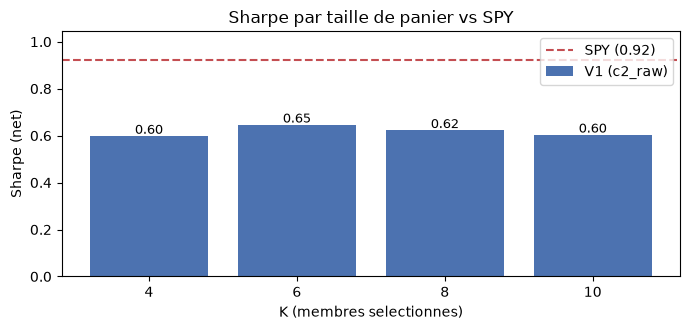

In [31]:
# Barres Sharpe par K vs SPY
fig, ax = plt.subplots(figsize=(7, 3.4))
Ks = [int(k) for k in kt.index]; shs = kt['sharpe'].values
ax.bar([str(k) for k in Ks], shs, color='#4C72B0', label=f'V1 ({best})')
ax.axhline(spy_sh, color='#C44E52', ls='--', lw=1.5, label=f'SPY ({spy_sh:.2f})')
for x, s in enumerate(shs): ax.text(x, s + 0.01, f'{s:.2f}', ha='center', fontsize=9)
ax.set_xlabel('K (membres selectionnes)'); ax.set_ylabel('Sharpe (net)')
ax.set_title('Sharpe par taille de panier vs SPY'); ax.set_ylim(0, max(shs.max(), spy_sh) + 0.12)
ax.legend(); plt.tight_layout(); plt.show()

**Lecture.**
- **K=6 pic** (Sharpe 0,65) ; K=4/8/10 entre 0,60 et 0,62. Aucun K ne franchit **SPY 0,92**.
- **Deflated Sharpe = 0,79** après **44 essais** (E[max] chance = 0,43) — **nettement sous 0,95** : le « gagnant » est indistinct du hasard.

### 5.5 Niveau-trade + persistance (le test décisif)

- Portefeuille **V1 retenu** (meilleur critère, K=6) au **niveau du trade** : hit rate, profit factor, espérance et médiane de l'anormal.
- Membres porteurs (AR moyen, ≥10 trades dans V1).
- **Persistance** : classement **in-sample 2020-22**, on regarde où finissent les **top-10** en **out-of-sample 2023-25**. Un signal réel persiste ; la chance se renverse.

In [32]:
# Portefeuille V1 retenu : meilleur critere, K=6 -> niveau trade
sel_best = {y: (select_K(sc_cache[y], 6, best) if len(sc_cache[y]) else []) for y in range(2014, 2026)}
gb_best = gate_buys(buys, sel_best)
tr = trade_returns(build_positions(gb_best, df, 12, sell_map=SELL_MAP), panel, RSP)
ts = trade_stats(tr)
print(f"V1 ({best}, K=6) niveau-trade : n={ts['n']} | hit={ts['hit_rate']:.0%} | PF={ts['profit_factor']:.2f} | "
      f"E[abn]={ts['esperance_abn']:+.2%} | mediane={ts['mediane_abn']:+.2%}")

# Membres porteurs du V1 (>=10 trades), tries par rdt anormal moyen
gm = gb_best.dropna(subset=['tret']).groupby('bioguide').agg(name=('name','first'), n=('tret','size'), tret=('tret','mean'))
gm = gm[gm['n'] >= 10].sort_values('tret', ascending=False)
print('\nMembres porteurs (V1, >=10 trades) :')
print(gm.head(6).to_string(formatters={'tret':'{:+.1%}'.format}))

V1 (c2_raw, K=6) niveau-trade : n=1383 | hit=49% | PF=1.39 | E[abn]=+2.72% | mediane=-0.39%

Membres porteurs (V1, >=10 trades) :
                         name    n   tret
bioguide                                 
C000071             Dave Camp   21 +15.6%
M001198     Roger W. Marshall   19 +10.8%
R000122           John F Reed   31 +10.3%
W000802    Sheldon Whitehouse  139 +10.3%
P000197          Nancy Pelosi   15 +10.0%
P000612   David A Perdue , Jr  475  +6.1%


In [33]:
# Persistance : classement in-sample 2020-22 -> out-of-sample 2023-25 (par exit_d realise)
def rank_window(y0, y1):
    sub = buys[(buys['exit_d'] >= pd.Timestamp(y0,1,1)) & (buys['exit_d'] <= pd.Timestamp(y1,12,31)) & buys['tret'].notna()]
    g = sub.groupby('bioguide')['tret']; m, n = g.mean(), g.size()
    return m[n >= 10].sort_values(ascending=False)

ins, oos = rank_window(2020, 2022), rank_window(2023, 2025)
top10 = list(ins.head(10).index)
oos_rank = {b: i+1 for i, b in enumerate(oos.index)}; n_oos = len(oos)
common = [b for b in top10 if b in oos.index]
mean_rank = np.mean([oos_rank[b] for b in common]) if common else np.nan
oos_top = oos.reindex(common).mean()
both = [b for b in ins.index if b in oos.index]
rho = stats.spearmanr(ins.reindex(both).values, oos.reindex(both).values).correlation
print(f"top-10 in-sample 2020-22 -> {len(common)}/10 encore eligibles 2023-25 | rang OOS moyen {mean_rank:.0f}/{n_oos}")
print(f"rdt anormal OOS des ex-top-10 : {oos_top:+.2%} | mediane du groupe OOS : {oos.median():+.2%}")
print(f"correlation de rang Spearman in/out ({len(both)} membres communs) : {rho:+.2f}")

top-10 in-sample 2020-22 -> 0/10 encore eligibles 2023-25 | rang OOS moyen nan/63
rdt anormal OOS des ex-top-10 : +nan% | mediane du groupe OOS : +1.15%
correlation de rang Spearman in/out (35 membres communs) : -0.11


**Lecture.**
- **Niveau-trade** : hit **49 %**, PF **1,39**, espérance **+2,72 %** mais **médiane −0,39 %** → une poignée de gros gagnants.
- **Persistance nulle** : top-10 in-sample 2020-22 → **0/10** encore éligibles 2023-25 ; Spearman in/out **−0,11**. Le passé ne dit rien du futur.

### Verdict — Partie 5
- **Meilleur critère** : c2_raw à K=6, Sharpe **0,65 < SPY 0,92**. Aucun critère à aucun K ne bat l'indice.
- **Les critères sophistiqués sur-apprennent** : c10_aCAPM/c11_aFFC4 → Sharpe 0,07/0,02, alphas **significativement négatifs** (~−12 %, t ≈ −2,3).
- **Deflated Sharpe 0,79** (44 essais) : le gagnant = **chance**.
- **Aucune persistance** : top-10 → **0/10** survivent, Spearman **−0,11**. → sélection par performance passée **non exploitable**.

## Partie 5bis — Juger au niveau *portefeuille du membre*

Un trade n'est pas une stratégie : un copieur détient le **portefeuille complet** d'un membre. On reprend l'analyse au niveau **portefeuille calendar-time** (capture chevauchement, diversification, timing ; **une observation par jour** → règle le biais d'event-study).

Trois choix :
- **Entrée = date `traded`** (réelle), pas `filed` : **TEST-PLAFOND** délibéré (information parfaite qu'aucun copieur n'a). *Si le portefeuille ne bat même pas le marché avec cet avantage, la version réaliste `filed+1` est morte d'avance.*
- **Benchmark style-matched par membre** : panier d'ETF sectoriels pondéré par sa propre allocation — sinon on récompenserait un simple **tilt sectoriel** comme du talent.
- **Deux livrables** : (1) juger en **Sharpe + IR** puis **refaire la sélection** (12ᵉ critère) ; (2) **décomposer** en sélection / timing / allocation.

> ⚠️ Rien ici n'est exploitable (on triche avec `traded`). Un résultat positif ne prouve qu'un plafond ; le négatif attendu **tue** la version réaliste.

### 5bis.0 Le socle — fondations `traded`, benchmark style, garde-fous

- **Fondations** : `buys_T` = `buys` avec `filed ← traded` ; `SELL_MAP_T` date aussi les ventes en `traded` ; `attach_realized` réécrit `tret`/`exit_d`.
- **Benchmark style** : $B_m(t) = \sum_s w_{m,s}\, r_{ETF(s)}(t)$, poids $w$ = part du \$ investi par ETF sectoriel (`ticker → t2etf`) ; sans secteur → **bucket RSP**. Version `as_of` (poids figés, sans look-ahead) et *dynamique* (re-figés chaque année).
- **Garde-fous** : **Golden #1** — AR 12 m = **+1,88 %** (entrée `traded`) / **+2,19 %** (entrée `filed`, = Partie 2.2). **Golden #2** — séries-membres reproduisent la Partie 5 (maxdiff 0).

In [34]:
# ===== 5bis.0 — SOCLE : fondations 'traded' + benchmark style-matched + garde-fous =====
import numpy as np, pandas as pd

# (1) Fondations 'traded' : on date l'ENTREE a la date reelle d'achat. Pattern valide en 2.2 (filed <- traded).
buys_T     = buys.assign(filed=buys['traded'])
SELL_MAP_T = build_sell_map(df.assign(filed=df['traded']))                      # sorties aussi datees 'traded'
buys_T     = attach_realized(buys_T, df, panel, RSP, 12, sell_map=SELL_MAP_T)   # reecrit traw/tret/exit_d/win

# (2) Series quotidiennes nettes PAR MEMBRE en base traded. build_all_member_series (Partie 0) rappelle
#     build_sell_map(df) en interne -> variante non destructrice qui accepte la sell-map (zero modif).
def build_all_member_series_v2(bq, df, panel, min_trades=10, sell_map=None):
    SM = sell_map if sell_map is not None else build_sell_map(df); out = {}
    for bio, g in bq.groupby('bioguide'):
        if len(g) < min_trades: continue
        tks = [t for t in g['ticker'].unique() if t in panel.columns]
        if not tks: continue
        out[bio] = run_portfolio(build_positions(g, df, 12, sell_map=SM), panel[tks], 'size', 20)['net']
    return out
member_daily_T = build_all_member_series_v2(buys_T, df, panel, sell_map=SELL_MAP_T)

# (3) Benchmark STYLE-MATCHED par membre : B_m(t) = somme_secteur w_{m,s} * r_ETF(s)(t).
ETF_RET = etfp.reindex(panel.index).ffill().pct_change(fill_method=None).fillna(0.0)
def member_style_bench(g, idx, as_of=None, fallback='RSP'):
    gg = g if as_of is None else g[g['filed'] <= as_of]
    total = float(gg['size_usd'].sum())
    if total <= 0 or len(gg) == 0: return ETF_RET[fallback].reindex(idx).fillna(0.0)
    w = gg.assign(_e=gg['ticker'].map(t2etf)).groupby('_e')['size_usd'].sum()   # cles NaN ignorees
    bench = pd.Series(0.0, index=idx); used = 0.0
    for e, sz in w.items():
        if e in ETF_RET.columns: bench = bench + (sz/total)*ETF_RET[e].reindex(idx).fillna(0.0); used += sz
    if total - used > 1e-9: bench = bench + ((total-used)/total)*ETF_RET[fallback].reindex(idx).fillna(0.0)
    return bench
def member_style_bench_dynamic(g, idx, fallback='RSP'):     # poids re-figes chaque annee (info debut d'annee)
    out = pd.Series(0.0, index=idx)
    for Y in sorted(set(idx.year)):
        out.loc[idx.year == Y] = member_style_bench(g, idx, as_of=pd.Timestamp(Y-1,12,31), fallback=fallback).loc[idx.year == Y]
    return out
def etf_coverage(g):
    tot = float(g['size_usd'].sum())
    return float(g.assign(_e=g['ticker'].map(t2etf)).dropna(subset=['_e'])['size_usd'].sum())/tot if tot>0 else 0.0

# (4) GARDE-FOUS (goldens)
_b = buys.dropna(subset=['car12'])
g1_traded = float(np.nanmean(abn_col(_b.assign(filed=_b['traded']), RSP, 252)))
g1_filed  = float(np.nanmean(_b['car12'].values))
_md_ref = member_daily                                   # defini en 5.2 (base filed)
_md_chk = build_all_member_series_v2(buys, df, panel)
_g2 = max((_md_ref[k]-_md_chk[k]).abs().max() for k in _md_ref) if set(_md_ref)==set(_md_chk) else float('nan')

print(f"[GOLDEN #1] CAR12  entree traded = {g1_traded:+.4f}  |  entree filed = {g1_filed:+.4f}  (= moyenne car12 Partie 2.2 {buys['car12'].mean():+.4f})")
print(f"[GOLDEN #2] series-membres v2 vs Partie 5 : maxdiff = {_g2:.1e}  (doit etre 0)  |  membres notes : {len(member_daily_T)}")
print(f"[FONDATIONS] buys_T {buys_T.shape} | SELL_MAP_T {len(SELL_MAP_T)} | mediane exit_d  traded {buys_T['exit_d'].median().date()} vs filed {buys['exit_d'].median().date()}")

[GOLDEN #1] CAR12  entree traded = +0.0188  |  entree filed = +0.0219  (= moyenne car12 Partie 2.2 +0.0219)
[GOLDEN #2] series-membres v2 vs Partie 5 : maxdiff = 0.0e+00  (doit etre 0)  |  membres notes : 192
[FONDATIONS] buys_T (68250, 41) | SELL_MAP_T 19730 | mediane exit_d  traded 2020-05-20 vs filed 2020-09-03


### 5bis.1 Chaque membre jugé comme un portefeuille

- Série quotidienne nette (entrée `traded`) notée comme un fonds.
- **Métriques** : `Sharpe`, `Sortino`, **`IR_style`** (vs benchmark de style), `IR_RSP`, **alpha CAPM** + son *t*.
- **Lecture** : `IR_style > 0` = bat son propre style ; `Sharpe > SPY` = bat l'indice ; `aCAPM_t > 2` = alpha crédible. `cov` = part du \$ couverte par un ETF.

In [35]:
# ===== 5bis.1 — Jugement de chaque membre comme un PORTEFEUILLE (entree traded) =====
spy_d  = bench_daily(SPY, panel.index); spy_sh = sharpe(spy_d)
_rows = []
for bio, d in member_daily_T.items():
    g = buys_T[buys_T['bioguide'] == bio]; idx = d.index
    bsm = member_style_bench(g, idx)                 # benchmark style plein-echantillon (diagnostic global)
    a   = factor_alpha(d, factors, 'capm')
    _rows.append({'name': g['name'].iloc[0], 'n': len(g), 'Sharpe': sharpe(d), 'Sortino': sortino(d),
                  'IR_style': info_ratio(d, bsm), 'IR_RSP': info_ratio(d, bench_daily(RSP, idx)),
                  'aCAPM': a['alpha_annuel'], 'aCAPM_t': a['alpha_t'], 'cov': etf_coverage(g)})
mem = pd.DataFrame(_rows)
print(f"{len(mem)} membres juges au niveau portefeuille (entree traded = information parfaite) | SPY Sharpe = {spy_sh:.2f}\n")
print(f"  IR vs style > 0 : {(mem['IR_style']>0).mean():.0%}   |   Sharpe > SPY : {(mem['Sharpe']>spy_sh).mean():.0%}   |   alpha CAPM significatif (t>2) : {(mem['aCAPM_t']>2).mean():.0%}")
print(f"  mediane IR vs style = {mem['IR_style'].median():+.2f}   |   mediane Sharpe = {mem['Sharpe'].median():.2f}")
_fmt = {'Sharpe':'{:.2f}'.format,'Sortino':'{:.2f}'.format,'IR_style':'{:+.2f}'.format,'IR_RSP':'{:+.2f}'.format,
        'aCAPM':'{:+.1%}'.format,'aCAPM_t':'{:+.2f}'.format,'cov':'{:.0%}'.format}
print("\nTop 6 par IR vs style :")
print(mem.sort_values('IR_style', ascending=False).head(6).to_string(index=False, formatters=_fmt))
print("\nBottom 4 par IR vs style :")
print(mem.sort_values('IR_style').head(4).to_string(index=False, formatters=_fmt))

192 membres juges au niveau portefeuille (entree traded = information parfaite) | SPY Sharpe = 0.92

  IR vs style > 0 : 4%   |   Sharpe > SPY : 0%   |   alpha CAPM significatif (t>2) : 0%
  mediane IR vs style = -0.69   |   mediane Sharpe = 0.34

Top 6 par IR vs style :
               name    n Sharpe Sortino IR_style IR_RSP aCAPM aCAPM_t  cov
       Nancy Pelosi   72   0.83    1.03    +0.25  +0.34 +8.7%   +1.50 100%
      Pete Sessions  228   0.87    1.09    +0.19  +0.18 +6.3%   +1.43  95%
       Dwight Evans   94   0.84    0.89    +0.18  +0.18 +5.1%   +1.32  98%
 RICHARD BLUMENTHAL   15   0.30    0.20    +0.06  -0.14 -0.1%   -0.01  99%
David A Perdue , Jr 1234   0.49    0.42    +0.05  -0.03 +3.6%   +0.49  87%
    Victoria Spartz   22   0.46    0.39    +0.03  -0.35 +1.2%   +0.29 100%

Bottom 4 par IR vs style :
          name   n Sharpe Sortino IR_style IR_RSP  aCAPM aCAPM_t  cov
  John McGuire  10  -0.42   -0.11    -1.04  -0.92  -6.9%   -2.06 100%
  Marie Newman 132  -0.25   -0.14  

**Lecture 5bis.1.**
- Sur **192 membres** jugés *avec information parfaite* (`traded`) : **4 %** battent leur style, **0 %** dépassent le Sharpe de SPY (0,92), **0 %** ont un alpha CAPM significatif.
- **Médiane IR vs style = −0,69**, médiane Sharpe **0,34** : le membre typique sous-performe son propre panier d'ETF sectoriel — et c'est déjà le meilleur cas (entrée parfaite, survivorship en faveur).

### 5bis.2 La sélection refaite sur un critère *portefeuille* (c12 = IR vs style)

- **12ᵉ critère `c12_ir`** = IR du **portefeuille calendar-time** vs son benchmark de style (figé fin N, sans look-ahead), puis walk-forward identique (K=6, 20 bps).
- **Comparaisons** : témoin `c10_aCAPM` filed (doit reproduire la Partie 5), puis `c12_ir` en **filed** (exploitable) et **traded** (plafond), face à SPY.
- **Deflated Sharpe** recalculé avec **48 essais** (12 critères × 4 K).

In [36]:
# ===== 5bis.2 — Selection refaite sur un critere PORTEFEUILLE (c12 = IR vs style) =====
# member_scores_v2 = les 11 criteres de la Partie 5 + c12_ir (variante non destructrice).
def member_scores_v2(bq, year, keymap, member_daily=None, factors=None, ucb_c=0.5, min_trades=10):
    past = bq[(bq['exit_d'] <= pd.Timestamp(year,12,31)) & bq['tret'].notna()]
    g = past.groupby('bioguide'); n = g.size(); elig = n[n >= min_trades].index
    if not len(elig): return pd.DataFrame()
    raw_sh = (g['tret'].mean()/(g['tret'].std(ddof=1)+1e-9)).reindex(elig); grp = float(raw_sh.mean()); N = int(n[elig].sum())
    name_of = past.drop_duplicates('bioguide').set_index('bioguide')['name']; cut = pd.Timestamp(year,12,31); rr = []
    for bio in elig:
        a = past.loc[past.bioguide==bio,'tret'].values; aw = past.loc[past.bioguide==bio,'traw'].values; ni = len(a)
        wins = a[a>0]; loss = a[a<=0]; pf = wins.sum()/abs(loss.sum()) if loss.sum()!=0 else 10.0
        sh = a.mean()/(a.std(ddof=1)+1e-9); shk = shrunk_sharpe(a, grp)
        d = member_daily.get(bio) if member_daily is not None else None
        if d is not None: d = d[d.index <= cut]
        c12 = info_ratio(d, member_style_bench(past.loc[past.bioguide==bio], d.index, as_of=cut)) if (d is not None and len(d) > 20) else np.nan
        rr.append({'bioguide':bio,'name':name_of.get(bio,bio),'n':ni,'c1_hit':(a>0).mean(),'c2_raw':aw.mean(),
            'c3_abn':a.mean(),'c4_med':np.median(a),'c5_pf':min(pf,10.0),'c6_sharpe':sh,'c7_shrunk':shk,
            'c8_ucb':shk+ucb_c*np.sqrt(np.log(N)/ni),'c9_t':a.mean()/(a.std(ddof=1)/np.sqrt(ni)+1e-9),
            'c10_aCAPM':(factor_alpha(d,factors,'capm')['alpha_annuel'] if d is not None and factors is not None else np.nan),
            'c11_aFFC4':(factor_alpha(d,factors,'ffc4')['alpha_annuel'] if d is not None and factors is not None else np.nan),
            'c12_ir':c12,'key':key_at(bio,year,keymap)})
    return pd.DataFrame(rr)

def wf_run2(col, K=6, weighting='size', sc=None, bq=None, sell_map=None):
    sel = {y: (select_K(sc[y], K, col) if len(sc[y]) else []) for y in range(2014, 2026)}
    gb = gate_buys(bq, sel)
    if not len(gb): return None
    res = run_portfolio(build_positions(gb, df, 12, sell_map=sell_map), panel, weighting, 20); net = res['net']; st = ann_stats(net)
    capm = factor_alpha(net, factors, 'capm'); ffc4 = factor_alpha(net, factors, 'ffc4')
    return {'n_pos':res['n_positions'],'CAGR':st['CAGR'],'sharpe':st['sharpe'],'maxDD':st['maxDD'],
            'aCAPM':capm['alpha_annuel'],'aCAPM_t':capm['alpha_t'],'aFFC4':ffc4['alpha_annuel'],'aFFC4_t':ffc4['alpha_t'],'net':net}

CRITERIA_V2 = CRITERIA + ['c12_ir']
sc_F = {y: member_scores_v2(buys,   y, keymap, member_daily,   factors) for y in range(2014, 2026)}  # base filed
sc_T = {y: member_scores_v2(buys_T, y, keymap, member_daily_T, factors) for y in range(2014, 2026)}  # base traded

rows_F = {c: wf_run2(c, sc=sc_F, bq=buys,   sell_map=SELL_MAP)   for c in CRITERIA_V2}   # exploitable
rows_T = {c: wf_run2(c, sc=sc_T, bq=buys_T, sell_map=SELL_MAP_T) for c in CRITERIA_V2}   # plafond (info parfaite)
spy_sh_wf = sharpe(bench_daily(SPY, rows_T['c12_ir']['net'].index))

tab = pd.DataFrame({c: {'Sharpe_filed': rows_F[c]['sharpe'], 'Sharpe_traded': rows_T[c]['sharpe'],
                        'aCAPMt_traded': rows_T[c]['aCAPM_t'], 'aFFC4t_traded': rows_T[c]['aFFC4_t']}
                    for c in CRITERIA_V2}).T
print(f"[NON-REGRESSION] c10_aCAPM base filed Sharpe {rows_F['c10_aCAPM']['sharpe']:.2f} (= Partie 5 {tbl.loc['c10_aCAPM','sharpe']:.2f})  |  SPY Sharpe {spy_sh_wf:.2f}\n")
print("Walk-forward des 12 criteres (K=6) — Sharpe (filed/traded) et alpha-t du portefeuille selectionne :")
print(tab.to_string(formatters={'Sharpe_filed':'{:.2f}'.format,'Sharpe_traded':'{:.2f}'.format,
                                'aCAPMt_traded':'{:+.2f}'.format,'aFFC4t_traded':'{:+.2f}'.format}))

# Deflated Sharpe : 12 criteres x 4 paniers K = 48 essais (base traded = plafond)
n_trials = len(CRITERIA_V2) * 4
sr_std = float(np.std([r['sharpe']/np.sqrt(252) for r in rows_T.values() if r], ddof=1))
best_T = max((c for c in rows_T if rows_T[c]), key=lambda c: rows_T[c]['sharpe'])
dsr = deflated_sharpe(rows_T[best_T]['net'], sr_std, n_trials)
print(f"\nCritere portefeuille c12_ir : filed {rows_F['c12_ir']['sharpe']:.2f} / traded {rows_T['c12_ir']['sharpe']:.2f}  vs SPY {spy_sh_wf:.2f}")
print(f"Meilleur des 12 (plafond traded) : {best_T} = Sharpe {rows_T[best_T]['sharpe']:.2f}, MAIS alpha CAPM t={rows_T[best_T]['aCAPM_t']:+.2f} / FFC4 t={rows_T[best_T]['aFFC4_t']:+.2f} (|t|<2 => NON significatif)")
print(f"   -> en base reelle (filed), {best_T} retombe a Sharpe {rows_F[best_T]['sharpe']:.2f}")
print(f"Deflated Sharpe ({n_trials} essais) = {dsr:.2f} (seuil 0,95) : {'franchi' if dsr>0.95 else 'NON franchi'} ; de toute facon porte par le Sharpe BRUT (beta), pas par un alpha (|t|<2)")

[NON-REGRESSION] c10_aCAPM base filed Sharpe 0.07 (= Partie 5 0.07)  |  SPY Sharpe 0.92

Walk-forward des 12 criteres (K=6) — Sharpe (filed/traded) et alpha-t du portefeuille selectionne :
          Sharpe_filed Sharpe_traded aCAPMt_traded aFFC4t_traded
c1_hit            0.46          0.46         +0.02         +0.11
c2_raw            0.65          0.55         -0.54         -0.58
c3_abn            0.41          0.58         -0.24         -0.19
c4_med            0.58          0.72         +0.77         +0.78
c5_pf             0.52          0.37         -0.94         -0.96
c6_sharpe         0.50          0.16         -2.03         -1.91
c7_shrunk         0.48          0.33         -0.91         -0.65
c8_ucb            0.53          0.47         -0.34         -0.32
c9_t              0.57          0.56         -0.56         -0.33
c10_aCAPM         0.07          0.68         +0.49         +0.45
c11_aFFC4         0.02          0.68         +0.50         +0.47
c12_ir            0.55         

**Lecture 5bis.2.**
- **Non-régression OK** : `c10_aCAPM` filed reproduit la **Partie 5** (Sharpe 0,07) ; SPY 0,92.
- **`c12_ir` ne bat pas le marché** : Sharpe **0,55 filed / 0,65 traded < SPY 0,92**.
- **Même au plafond**, le meilleur des 12 choisi a posteriori (`c4_med`) fait Sharpe **0,72 < SPY 0,92**, alpha non significatif (t ≈ 0,78), et **DSR 0,90 < 0,95**. En `filed` réel : 0,58.
- *Même en trichant sur la date et en pêchant le meilleur critère*, **rien ne bat l'indice** et **aucun alpha**.

### 5bis.3 D'où vient le rendement actif : sélection, timing ou allocation ?

Décomposition du rendement actif (portefeuille − RSP) en trois briques additives (cadre **Brinson**, axe sectoriel) :
- **Sélection** = portefeuille − *son benchmark de style* (stock-picking intra-secteur) ;
- **Timing** = benchmark de style *dynamique* − *figé* (déplacer les poids au bon moment) ;
- **Allocation** = benchmark de style figé − RSP (tilt sectoriel = beta de style).
- **Identité** : `sélection + timing + allocation = portefeuille − RSP` (< 1e-9).
- **Limite** : décomposition **secteur** seulement (seul axe via `t2etf`) → « sélection » = intra-secteur, pas un alpha pur.

AGREGAT 'tout le Congres' — rendement actif vs RSP, decompose (CAGR annualise) :
   entree filed  : selection -3.53% | timing +0.31% | allocation +0.92% | TOTAL -2.34%   (recon 3e-18)
   entree traded : selection -2.71% | timing -0.61% | allocation +0.92% | TOTAL -2.39%   (recon 3e-18)



Par membre (entree traded) : selection > 0 chez 2% des 192 membres | mediane selection -11.6%


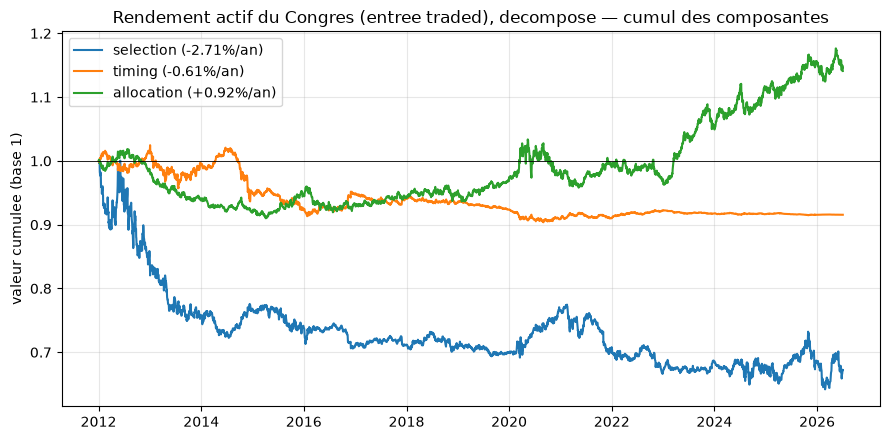

In [37]:
# ===== 5bis.3 — Decomposition Brinson : selection vs timing vs allocation =====
import matplotlib.pyplot as plt
def decompose(g, daily_net, idx):
    Bd = member_style_bench_dynamic(g, idx); Bs = member_style_bench(g, idx); rsp = bench_daily(RSP, idx)
    net = daily_net.reindex(idx).fillna(0.0)
    sel = net - Bd; tim = Bd - Bs; alc = Bs - rsp
    comp = {k: ann_stats(v)['CAGR'] for k, v in {'selection':sel,'timing':tim,'allocation':alc,'total':net-rsp}.items()}
    return comp, {'selection':sel,'timing':tim,'allocation':alc}, float((sel+tim+alc-(net-rsp)).abs().max())

# (a) Agregat 'tout le Congres' : filed vs traded
agg_F = run_portfolio(build_positions(buys,   df, 12, sell_map=SELL_MAP),   panel, 'size', 20)['net']
agg_T = run_portfolio(build_positions(buys_T, df, 12, sell_map=SELL_MAP_T), panel, 'size', 20)['net']
cF, _,  rF = decompose(buys,   agg_F, panel.index)
cT, sT, rT = decompose(buys_T, agg_T, panel.index)
print("AGREGAT 'tout le Congres' — rendement actif vs RSP, decompose (CAGR annualise) :")
print(f"   entree filed  : selection {cF['selection']:+.2%} | timing {cF['timing']:+.2%} | allocation {cF['allocation']:+.2%} | TOTAL {cF['total']:+.2%}   (recon {rF:.0e})")
print(f"   entree traded : selection {cT['selection']:+.2%} | timing {cT['timing']:+.2%} | allocation {cT['allocation']:+.2%} | TOTAL {cT['total']:+.2%}   (recon {rT:.0e})")

# (b) Par membre : combien ont un VRAI stock-picking (selection > 0) ?
_sels = []
for bio, d in member_daily_T.items():
    c, _, _ = decompose(buys_T[buys_T.bioguide==bio], d, d.index); _sels.append(c['selection'])
_sels = np.array(_sels)
print(f"\nPar membre (entree traded) : selection > 0 chez {(_sels>0).mean():.0%} des {len(_sels)} membres | mediane selection {np.median(_sels):+.1%}")

# (c) Equite cumulee des 3 composantes (agregat traded)
fig, ax = plt.subplots(figsize=(9,4.5))
for k, v in sT.items():
    ax.plot(v.index, (1+v).cumprod(), label=f"{k} ({cT[k]:+.2%}/an)")
ax.axhline(1, color='k', lw=.6)
ax.set_title("Rendement actif du Congres (entree traded), decompose — cumul des composantes")
ax.set_ylabel("valeur cumulee (base 1)"); ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

**Lecture 5bis.3.**
- **Le rendement actif agrégé est NÉGATIF** : entrée `filed` sélection **−3,53 %** / timing +0,31 % / allocation +0,92 % → **TOTAL −2,34 %/an** ; entrée `traded` → **−2,39 %**.
- La **sélection de titres détruit de la valeur** ; seule l'**allocation sectorielle** (+0,92 %) est positive, mais insuffisante.
- **Au niveau individuel** : **2 %** des membres ont un stock-picking positif ; **médiane sélection −11,6 %**.

### Verdict — Partie 5bis
- **Au plafond (`traded`, info parfaite), aucun portefeuille de membre ne bat le marché** : 192 membres, **4 %** battent leur style, **0 %** le Sharpe de SPY, **0 %** un alpha significatif (médiane IR vs style **−0,69**).
- **`c12_ir` ne sauve rien** : Sharpe **0,65 traded / 0,55 filed < SPY 0,92**.
- **Même le meilleur des 12 a posteriori** (`c4_med`) plafonne à **0,72 < SPY**, DSR **0,90 < 0,95**, sans alpha.
- **Le rendement actif est négatif** (**−2,3 %/an**) : sélection **−3,5 %**, seule l'allocation sectorielle est positive. **Pas d'alpha de sélection — que du beta de style.**

## 6. Mise en perspective — littérature & produits réels

Nos résultats **convergent avec la recherche récente (post-STOCK Act) et les produits réels**.

**Travaux fondateurs (le mythe)**
- **Ziobrowski et al. 2004** : sénateurs ≈ **+12 %/an** d'excès — mais **1993–1998**, avant toute divulgation (STOCK Act = 2012).
- **Ziobrowski et al. 2011** (House) : avantage **nettement plus faible** que le Sénat.

**Critiques**
- **Eggers & Hainmueller 2013, « Capitol Losses »** (https://andy.egge.rs/papers/Eggmueller_CapitolLosses.pdf) : la sur-performance **ne résiste pas** à une méthodologie corrigée.
- **Karadas 2019** : le meilleur prédicteur = **commissions clés**, mais ce signal **disparaît après ~2012** (STOCK Act).

**État de l'art post-STOCK Act**
- **Chen & Sacerdote, NBER w35041, 2026** (https://www.nber.org/papers/w35041) : les membres **« underperform or at best match »** le marché.
- **Wei & Zhou, NBER w34524, 2024** (https://www.nber.org/papers/w34524) : **+47 %/an**, mais **uniquement pour les « leaders »** (< 5–10 % des membres). Exactement notre « loterie de queue droite ».

**Produits & backtests commerciaux**
- **ETF NANC** ≈ marché ; **ETF KRUZ** sous-performe.
- **Quiver « Congress Buys »** (https://www.quiverquant.com/strategies/s/Congress%20Buys/) : backtests flatteurs **sans coûts ni slippage, look-ahead** (signal à la date *tradée*) — nous entrons à `filed + 1j` (28 j de latence médiane) avec **20 bps**.
- **Autopilot / « Pelosi » 2019–22** : a **sous-performé le S&P 500**.

**Synthèse** : le « hype » = un **narratif** + une **monétisation de la donnée**, pas une performance reproductible nette de coûts. Notre travail reproduit ce consensus sur 2014–2026, en point-in-time.

## 7. Verdict & recommandation (équipe QIS Ramify)

> Chaque nombre est calculé dans une cellule visible.

1. **Loterie de queue droite.** Vs RSP 12 m : moyenne **+2,19 %**, médiane **−1,43 %**, skew **14,0** ; le top-décile capte **60 %** des gains, sans lui **−6,52 %**. *(P.2)*
2. **Le benchmark change le niveau, pas la nature.** vs SPY **−0,16 %**, vs RSP **+2,19 %** ; médiane < 0 partout. *(P.2)*
3. **Commission clé = meilleur découpage mais s'évapore** : +3,47 % (t naïf +11,33) → t clusterisé **+1,42**. *(P.3)*
4. **Copier tout ≈ le marché, en pire** : Sharpe **0,68 < SPY 0,92**, β ≈ 0,95, **alpha FFC4 négatif** (jusqu'à −2,25 %, t −2,09) ; **GRS ne rejette pas** « alphas = 0 ». *(P.4)*
5. **La sélection ne sauve rien** : meilleur Sharpe **0,65 < SPY 0,92** ; les critères d'alpha individuel **détruisent** la valeur (α ≈ −12 %, t ≈ −2,3) ; **Deflated Sharpe 0,79** ; **0/10** de persistance. *(P.5)*
6. **Alpha de sélection nul** : au plafond (`traded`), rendement actif **négatif** (−2,3 %/an), sélection **−3,5 %** ; seule l'allocation sectorielle est positive. *(P.5bis)*

**Recommandation**
- **NE PAS positionner ce signal comme un générateur d'alpha** : l'edge net de coûts est nul, voire négatif.
- **Un produit *thématique*** (type NANC/KRUZ) reste envisageable — décision marketing, pas une promesse de surperformance.
- **Si panier : pondérer *tout le Congrès*** plutôt qu'une sélection (moins de data-snooping).
- **Suite** : reconstruire l'univers **point-in-time AVEC les délistés** pour tuer le survivorship.

### Limites & traçabilité
**Limites**
- **Survivorship** : **2 745 / 3 700** tickers ont un prix → **~955 délistés absents** (surtout des perdants) → **rendements = bornes hautes**.
- **2014-2019 plus mince** (45,8 %) ; **2026 partiel** (prix → juillet 2026) → AR 12 m censuré au-delà de ~mi-2025.

**Traçabilité**
- **Donnée clean canonique source-primaire** (`transactions_backtest_2014_2026.csv`) + tickers `ticker_yahoo` + cache `prices_v2` — même socle que le notebook 05b.
- **Commissions clés point-in-time** (`key_at` par Congrès). **Zéro chiffre orphelin** ; littérature sourcée (section 6).